In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)

In [3]:
label_df.reset_index(inplace=True)
label_df["index"] = label_df.index.astype(np.int32)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered)
print(label_df_filtered["label"].value_counts())

             index        label_id  depth  label  dom_label   5mer  drach
0                0    NM_000084:34      7      0        0.0  GCAGA  False
1                1    NM_000084:36      7      0        0.0  AGAGA  False
2                2    NM_000084:38      7      0        0.0  AGAAT  False
3                3    NM_000084:39      7      0        0.0  GAATG  False
4                4    NM_000084:43      7      0        0.0  GCAGC  False
...            ...             ...    ...    ...        ...    ...    ...
30960221  30960221  NR_176252:1213     37      0        0.0  TTACT  False
30960222  30960222  NR_176252:1218     36      0        0.0  TTAAA  False
30960223  30960223  NR_176252:1219     36      0        0.0  TAAAA  False
30960224  30960224  NR_176252:1220     36      0        0.0  AAAAT  False
30960225  30960225  NR_176252:1221     36      0        0.0  AAATG  False

[18499997 rows x 7 columns]
label
0    18399879
1      100118
Name: count, dtype: int64


In [101]:
label_alt = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/label/GLORIPUB.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_alt = label_alt[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_alt.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_alt.reset_index(inplace=True)
label_alt["index"] = label_alt.index.astype(np.int32)
label_alt_filtered = label_alt[((label_alt["dom_label"] > 0.0) & (label_alt["label"] == 1)) | (label_alt["label"] == 0)]
print(label_alt_filtered)
print(label_alt_filtered["label"].value_counts())

             index        label_id  depth  label  dom_label   5mer  drach
362            362    NM_000986:32   8001      0        0.0  GGAGC  False
364            364    NM_000986:45   8014      0        0.0  TGAAG  False
365            365    NM_000986:46   8015      0        0.0  GAAGG  False
367            367    NM_000986:60   8027      0        0.0  GCAGT  False
369            369    NM_000986:73   8033      0        0.0  GTACA  False
...            ...             ...    ...    ...        ...    ...    ...
30959767  30959767  NR_182068:1325      6      0        0.0  ATAAA  False
30959768  30959768  NR_182068:1326      6      0        0.0  TAAAG  False
30959769  30959769  NR_182068:1327      6      0        0.0  AAAGC  False
30959770  30959770  NR_182068:1334      6      0        0.0  GTACC  False
30959771  30959771  NR_182068:1337      6      0        0.0  CCATG  False

[17310037 rows x 7 columns]
label
0    17226003
1       84034
Name: count, dtype: int64


In [4]:
dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl")
dorado_df = dorado_df[dorado_df["dorado_count"] >= 20]
dorado_df = dorado_df.merge(label_df_filtered, on="label_id", how="inner")
dorado_df = dorado_df[["pred_dorado", "dorado_count", "label_id"]]

In [5]:
logsum_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(logsum_df, allow_pickle=True) as data:
    logsum_df = pd.DataFrame({key: data[key] for key in data.keys()})
logsum_df = logsum_df[logsum_df["count_dom"] >= 20]
logsum_df = logsum_df.merge(label_df_filtered, on="label_id", how="inner")
logsum_df = logsum_df.merge(dorado_df, on="label_id", how="inner")
print(logsum_df)

                label_id     p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000  0.606511      0.000000        0.000000          0   
1         NM_000016:1008  0.948786      0.000000        0.000000          0   
2         NM_000016:1009  2.607620      0.000000        0.000000          0   
3         NM_000016:1010  4.912612      0.000000        0.000000          0   
4         NM_000016:1014  3.237954      0.000000        0.000000          0   
...                  ...       ...           ...             ...        ...   
10340557  NR_182669:3964  1.226287      0.000000        0.000000          0   
10340558  NR_182669:3965  1.268912      0.000000        0.000000          0   
10340559  NR_182669:3966  1.295230      0.000000        0.000000          0   
10340560  NR_182669:3968  2.394934     -0.006871       -1.804221          1   
10340561  NR_182669:3969  1.723521      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg  count_neg  

In [102]:
dorado_alt = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl")
dorado_alt = dorado_alt[dorado_alt["dorado_count"] >= 20]
dorado_alt = dorado_alt.merge(label_alt_filtered, on="label_id", how="inner")
dorado_alt = dorado_alt[["pred_dorado", "dorado_count", "label_id"]]

In [103]:
logsum_alt = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(logsum_alt, allow_pickle=True) as data:
    logsum_alt = pd.DataFrame({key: data[key] for key in data.keys()})
logsum_alt = logsum_alt[logsum_alt["count_dom"] >= 20]
logsum_alt = logsum_alt.merge(label_alt_filtered, on="label_id", how="inner")
logsum_alt = logsum_alt.merge(dorado_df, on="label_id", how="inner")
print(logsum_alt)

               label_id     p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0        NM_000016:1000  0.606511      0.000000        0.000000          0   
1        NM_000016:1008  0.948786      0.000000        0.000000          0   
2        NM_000016:1009  2.607620      0.000000        0.000000          0   
3        NM_000016:1010  4.912612      0.000000        0.000000          0   
4        NM_000016:1014  3.237954      0.000000        0.000000          0   
...                 ...       ...           ...             ...        ...   
9515923  NR_182669:3964  1.226287      0.000000        0.000000          0   
9515924  NR_182669:3965  1.268912      0.000000        0.000000          0   
9515925  NR_182669:3966  1.295230      0.000000        0.000000          0   
9515926  NR_182669:3968  2.394934     -0.006871       -1.804221          1   
9515927  NR_182669:3969  1.723521      0.000000        0.000000          0   

         logsum_p_neg  logsum_1_p_neg  count_neg  logsum_p_all 

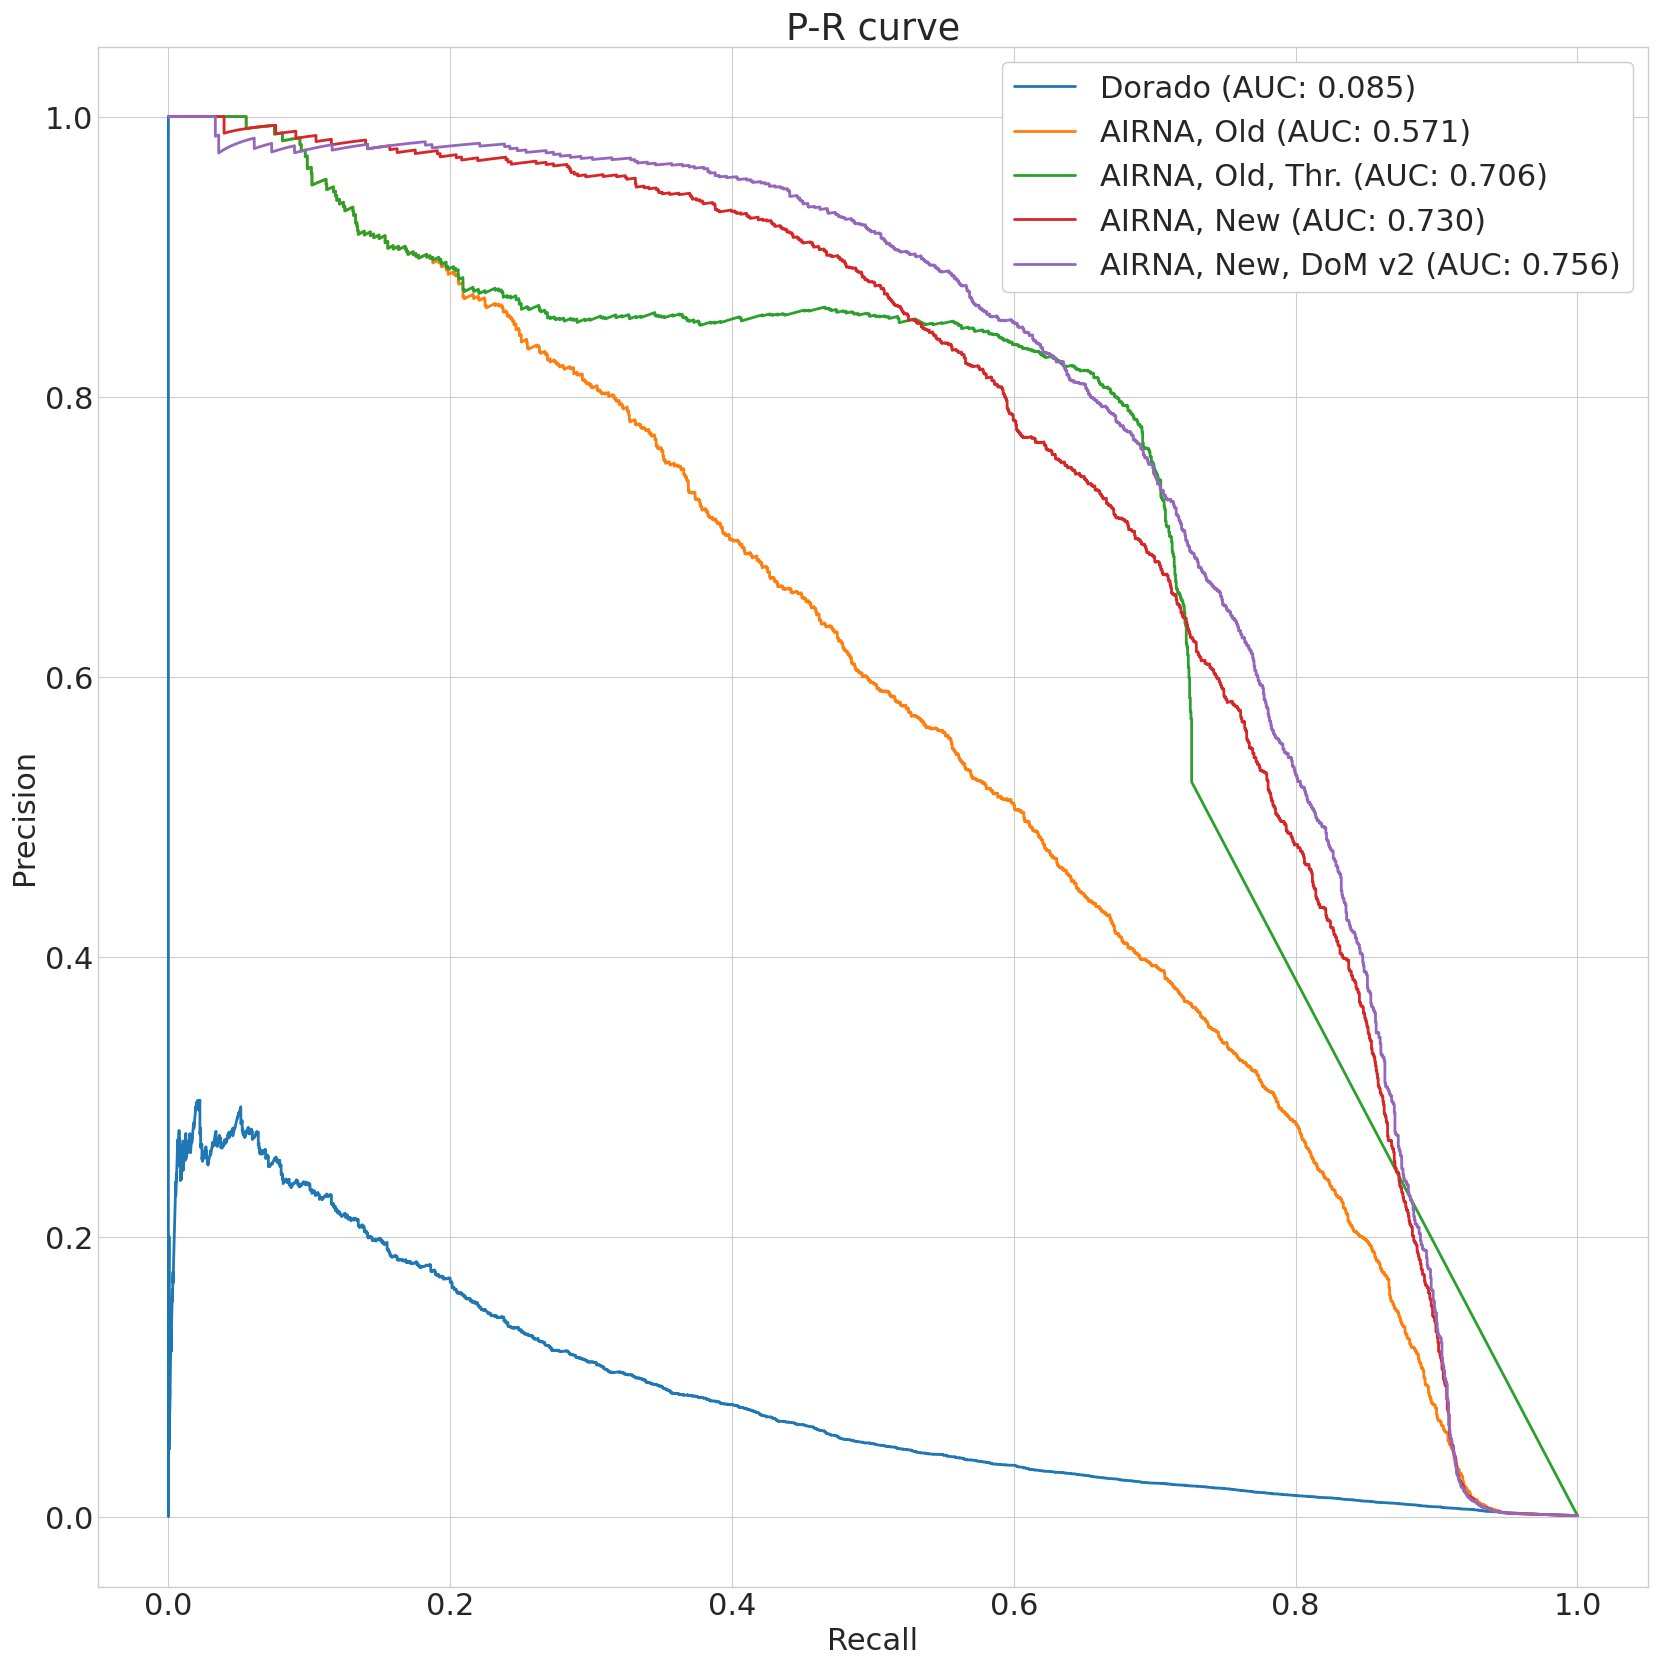

In [6]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["dorado_count"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

selected_df["pm6a_neg"] =  1-10**((selected_df["logsum_1_p_pos"]+selected_df["logsum_1_p_neg"])/(selected_df["count_pos"]+selected_df["count_neg"]))
selected_df["threshold"] = 1-((0.9 ** (1-selected_df["dom"])) * (0.02 ** (selected_df["dom"])))
selected_df["pm6a_neg_thr"] = selected_df["pm6a_neg"] * (selected_df["pm6a_neg"] > selected_df["threshold"])
selected_df["pm6a_pos"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["p_avg"] = selected_df["p_sum"] / selected_df["count_all"]
selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old, Thr. (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New, DoM v2 (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend(loc="upper right")
plt.show()

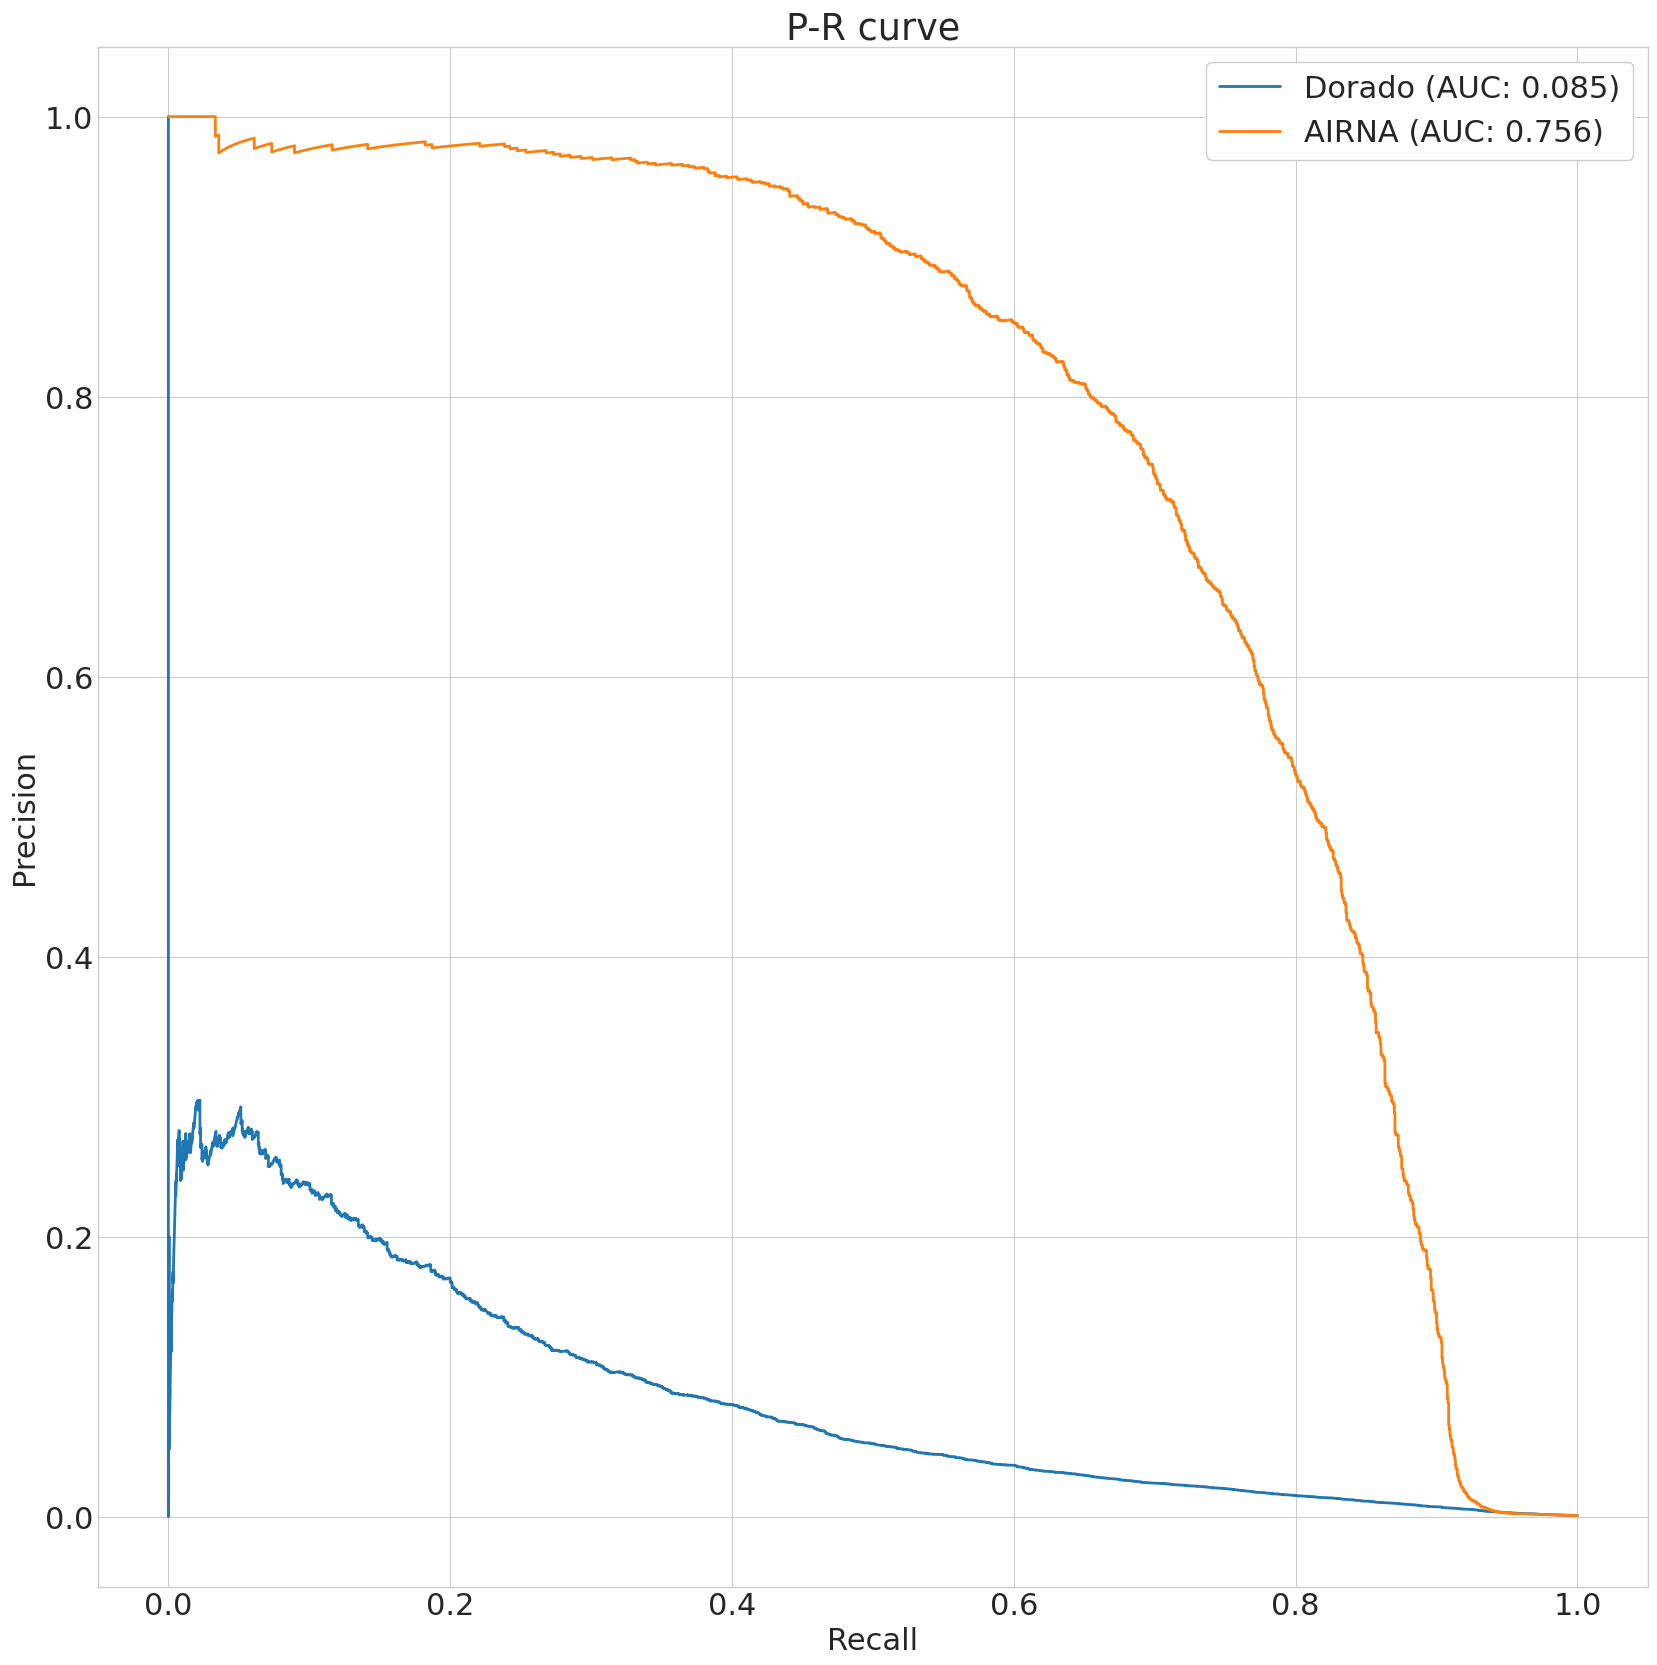

In [7]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["dorado_count"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend(loc="upper right")
plt.show()

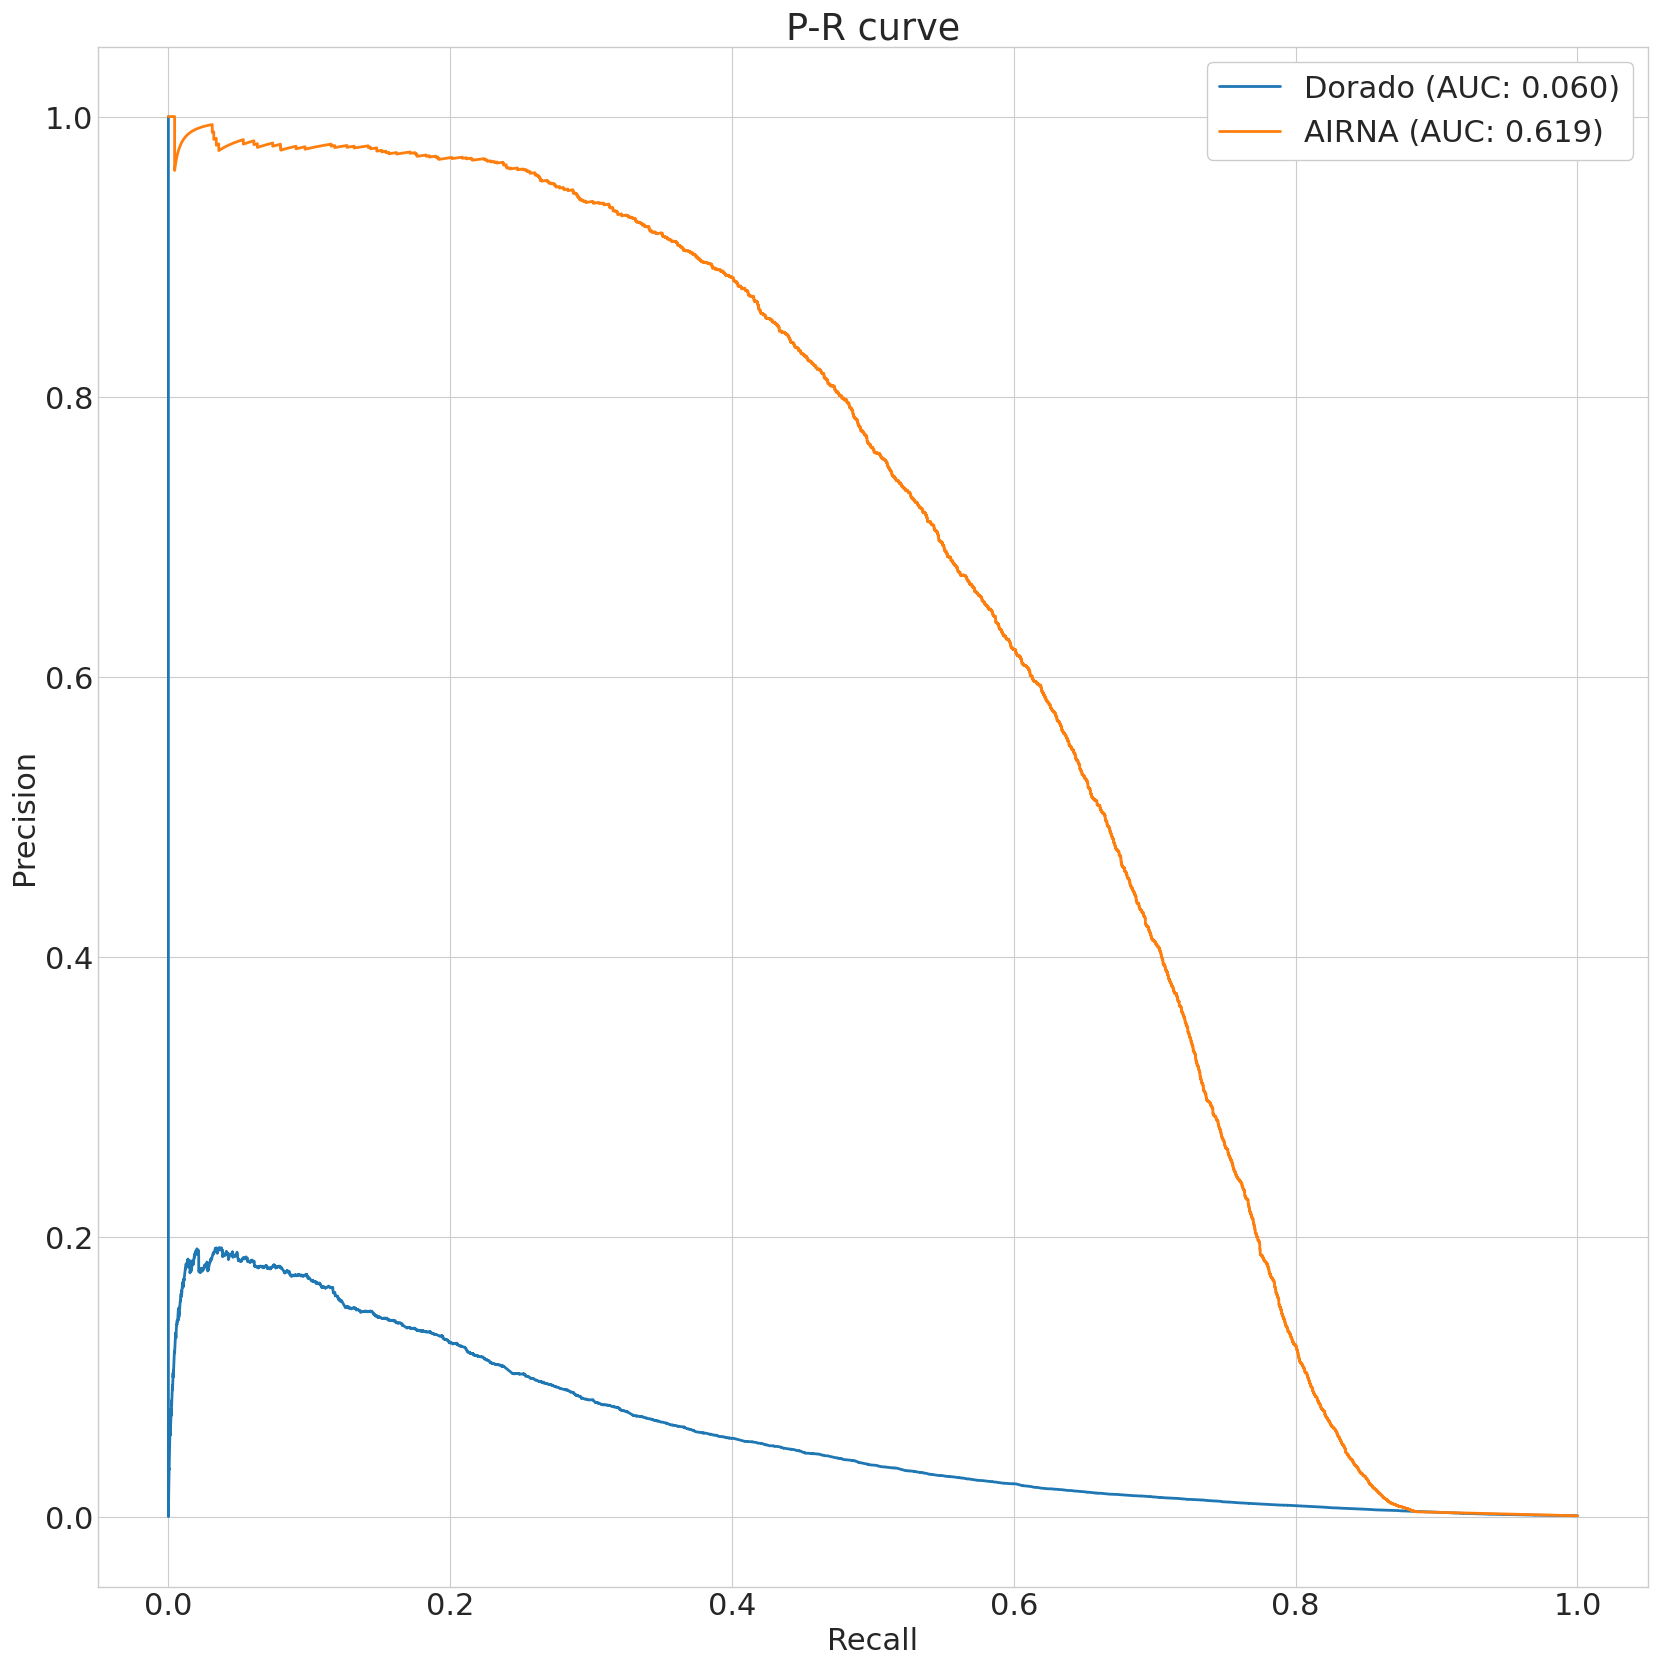

In [11]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 20) & (logsum_df["dorado_count"] >= 20) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend(loc="upper right")
plt.show()

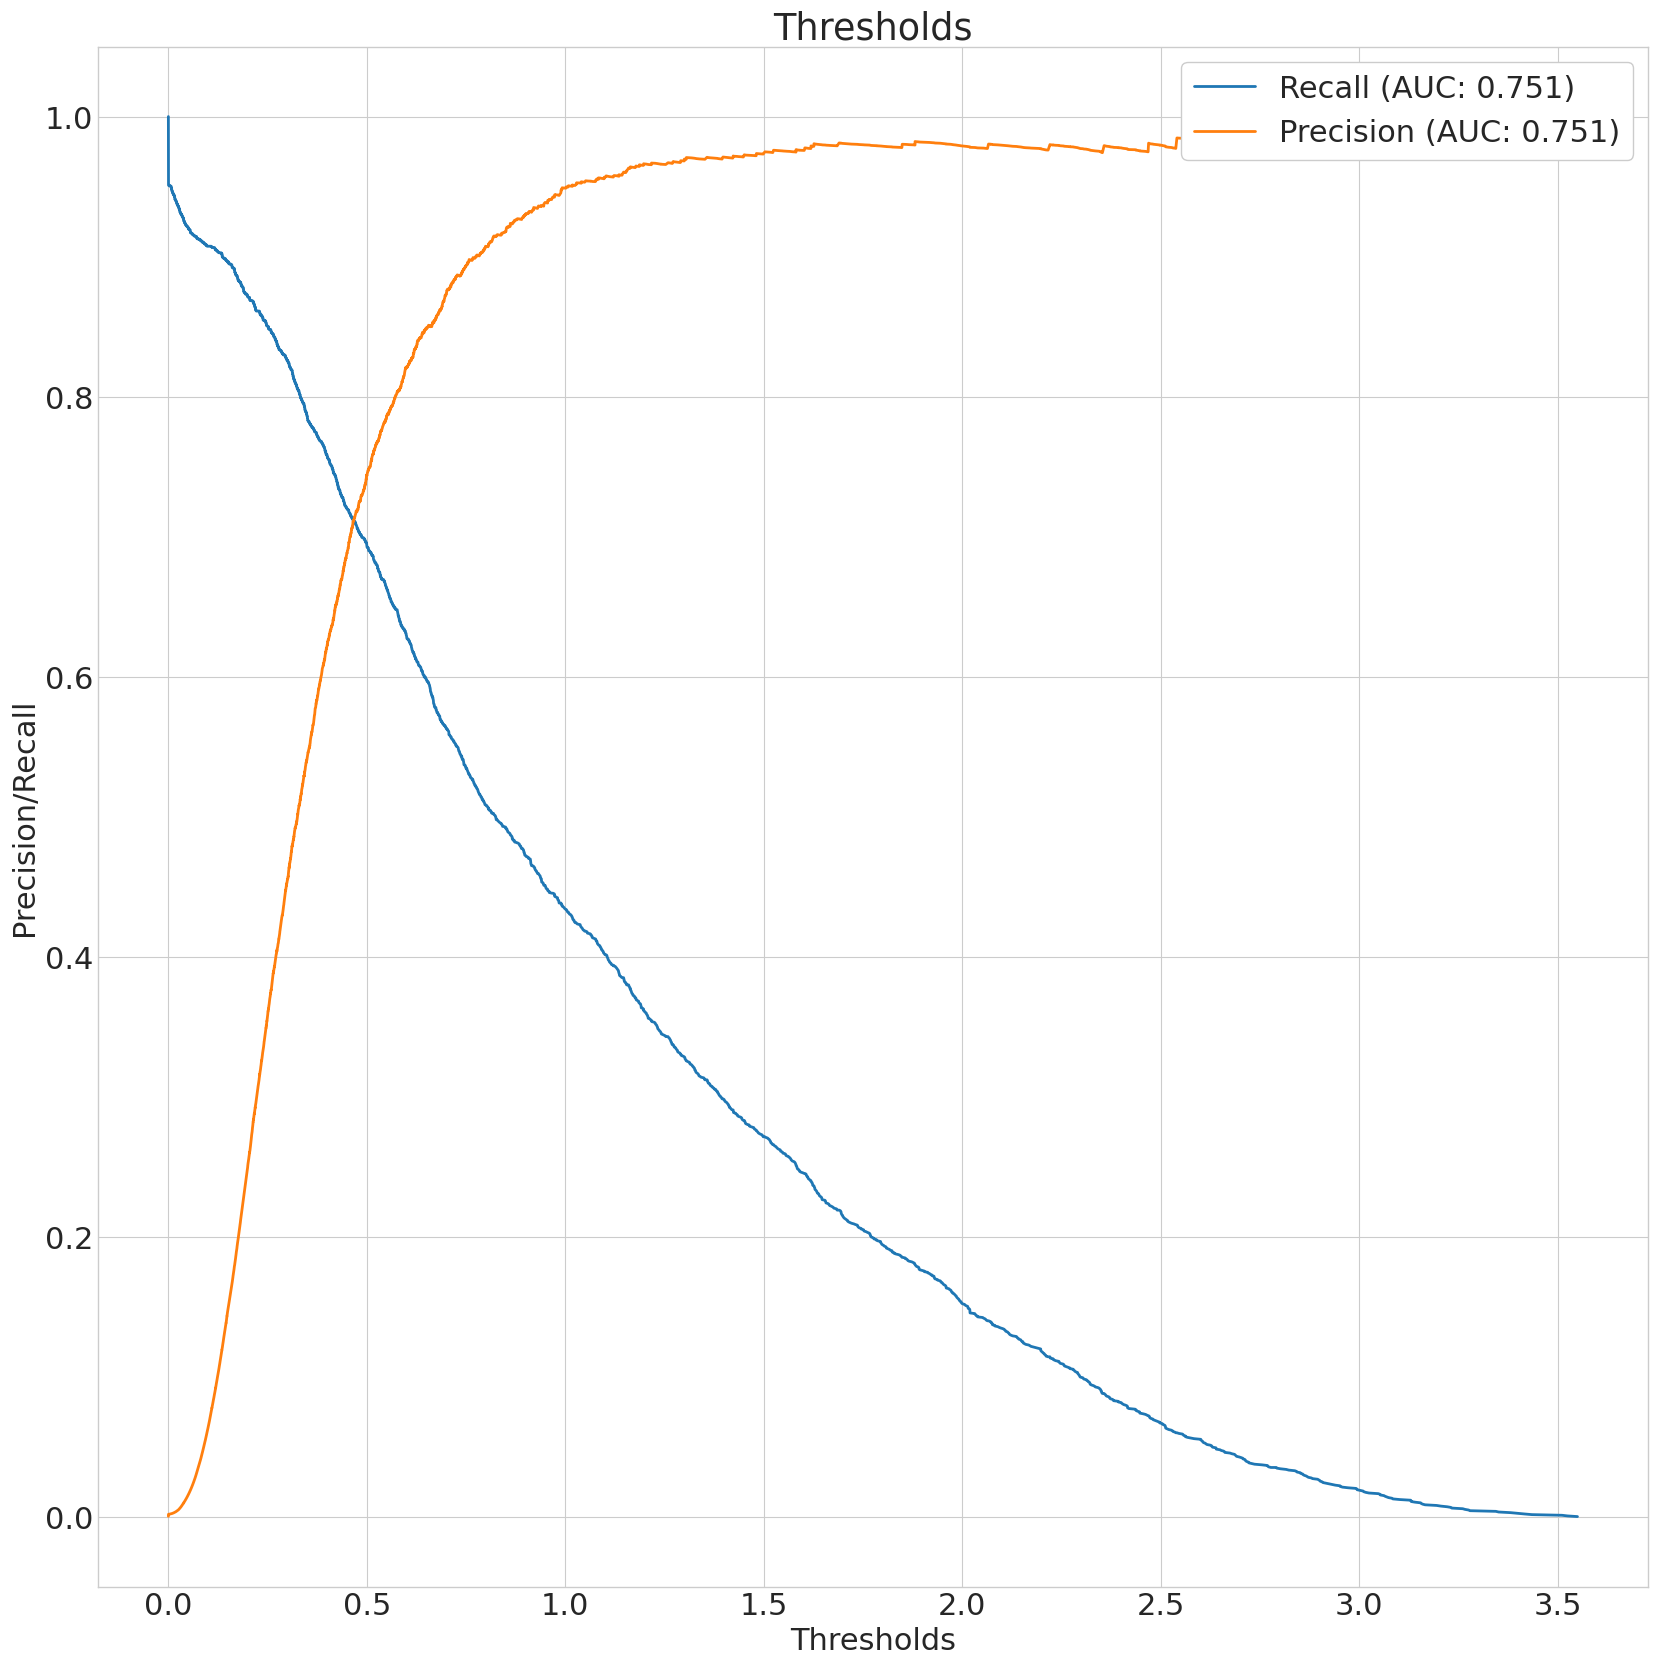

[0.00000000e+00 7.19095399e-05 8.70584494e-05 ... 3.51056390e+00
 3.52473203e+00 3.54958048e+00]


In [9]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(thresholds, recall[:-1], label=f"Recall (AUC: {auc_score:.3f})")
ax.plot(thresholds, precision[:-1], label=f"Precision (AUC: {auc_score:.3f})")

ax.set_xlabel("Thresholds")
ax.set_ylabel("Precision/Recall")
ax.set_title("Thresholds")
ax.legend(loc="upper right")
plt.show()

print(thresholds)

<Axes: >

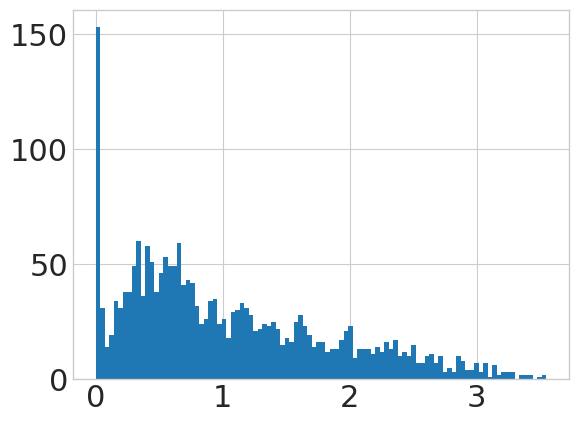

In [21]:
selected_df[selected_df["label"]==1]["pm6a_pos_dom_v2"].hist(bins=100)

In [23]:
selected_df[(selected_df["label"]==1) & (selected_df["pm6a_pos_dom_v2"] == 0.0)]

,label_id,p_sum,logsum_p_pos,logsum_1_p_pos,count_pos,logsum_p_neg,logsum_1_p_neg,count_neg,logsum_p_all,logsum_1_p_all,...,dom,count_dom,depth,label,dom_label,5mer,drach,pred_dorado,dorado_count,pm6a_pos_dom_v2
15151,NM_000113:24,3.333026,0.0,0.0,0,-984.767883,-0.292922,296,-989.415100,-1.989055,...,0.003333,300,364,1,0.102037,AGAAC,False,0.0000,354,-0.0
36491,NM_000194:27,5.974673,0.0,0.0,0,-368.602203,-0.757488,148,-374.052216,-3.554713,...,0.012987,154,176,1,0.115196,TCAGG,False,0.0064,156,-0.0
197810,NM_001003962:23,4.843415,0.0,0.0,0,-287.613739,-0.216413,107,-291.845428,-3.064121,...,0.009091,110,172,1,0.113953,GGAGC,False,0.0370,162,-0.0
347667,NM_001014436:4,5.254717,0.0,0.0,0,-302.242279,-0.358703,106,-309.766205,-3.488365,...,0.026316,114,142,1,0.101190,CTACA,False,0.0244,123,-0.0
392445,NM_001018108:34,35.137924,0.0,0.0,0,-2597.614014,-3.074229,969,-2634.582764,-22.198318,...,0.015920,1005,1204,1,0.136956,GCAGG,False,0.0779,1027,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9983983,NM_213720:21,16.234472,0.0,0.0,0,-236.124039,-0.770255,109,-251.374237,-11.516265,...,0.071429,126,183,1,0.126586,ACAAG,False,0.0240,167,-0.0
10073117,NR_037672:378,4.850079,0.0,0.0,0,-525.052124,-0.815662,198,-531.793884,-2.475751,...,0.004902,204,219,1,0.136956,GCAGG,False,0.0462,195,-0.0
10077062,NR_037853:617,6.251710,0.0,0.0,0,-277.258484,-0.277006,105,-285.209869,-4.145258,...,0.034783,115,130,1,0.569691,GCAGA,False,0.0180,111,-0.0
10288165,NR_155756:518,5.714204,0.0,0.0,0,-231.255142,-0.492335,98,-238.460754,-3.768551,...,0.019048,105,130,1,0.173577,GCAGC,False,0.0190,105,-0.0


In [32]:
selected_df[(selected_df["label"]==1)]

,label_id,p_sum,logsum_p_pos,logsum_1_p_pos,count_pos,logsum_p_neg,logsum_1_p_neg,count_neg,logsum_p_all,logsum_1_p_all,...,dom,count_dom,depth,label,dom_label,5mer,drach,pred_dorado,dorado_count,pm6a_pos_dom_v2
1659,NM_000021:1942,88.616447,-0.027510,-279.817352,83,-172.761902,-0.087137,58,-177.672791,-285.424133,...,0.586667,150,155,1,0.681758,GGACG,False,0.5695,151,2.441013
9649,NM_000077:6,20.494205,-0.008357,-1.719897,1,-1384.737061,-1.721116,503,-1410.044922,-15.969685,...,0.015123,529,724,1,0.321925,GCAGG,False,0.0700,586,0.006156
13295,NM_000098:943,23.932020,-0.006384,-47.663834,15,-384.779022,-0.376271,137,-390.123260,-55.601768,...,0.135802,162,171,1,0.204548,GTACA,False,0.2053,151,0.516568
15151,NM_000113:24,3.333026,0.000000,0.000000,0,-984.767883,-0.292922,296,-989.415100,-1.989055,...,0.003333,300,364,1,0.102037,AGAAC,False,0.0000,354,-0.000000
18283,NM_000126:26,12.546247,-0.003951,-2.043051,1,-937.564270,-0.830799,319,-948.979309,-10.096399,...,0.021148,331,397,1,0.170680,CCAGT,False,0.0436,344,0.011623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10304096,NR_163909:2006,17.469582,-0.017221,-36.163651,13,-333.469025,-0.267462,111,-337.072906,-40.426971,...,0.123077,130,140,1,0.134129,CGACA,False,0.1920,125,0.498261
10304501,NR_163922:461,46.646519,-0.032779,-79.223328,26,-451.251648,-1.385668,196,-477.696533,-92.345329,...,0.135802,243,273,1,0.103253,GGACG,False,0.0984,254,0.526478
10304841,NR_163924:596,32.716995,-0.018416,-62.043800,20,-196.709045,-0.709208,88,-208.427856,-72.232918,...,0.233871,124,135,1,0.103253,GGACG,False,0.1780,118,0.788368
10338640,NR_182661:1592,13.311136,-0.005288,-33.037907,10,-343.051544,-0.090198,101,-345.555664,-36.112457,...,0.104348,115,119,1,0.100199,GGATT,False,0.1111,117,0.522868


In [10]:
def load_npz(path_list):
    return_dict = {}
    for path in tqdm.tqdm(path_list):
        with np.load(path, allow_pickle=True) as data:
            for key in data.keys():
                if key not in return_dict:
                    return_dict[key] = []
                return_dict[key].append(data[key])
    return_dict = {key: np.concatenate(return_dict[key], axis=0) for key in return_dict.keys()}
    return return_dict
        

In [12]:
pos_data = load_npz(glob.glob("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/block_070/token_normalise_nondrach_poslabel/*.npz"))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 715/715 [03:26<00:00,  3.47it/s]


In [13]:
neg_data = load_npz(glob.glob("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/block_070/token_normalise_nondrach_neglabel/*.npz"))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 239/239 [00:55<00:00,  4.30it/s]


In [47]:
tss_data = load_npz(glob.glob("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/block_070/token_normalise_tss/*.npz"))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 699/699 [02:54<00:00,  4.02it/s]


In [14]:
pos_data["label_id_str"] = np.array([label_df["label_id"].loc[x] for x in pos_data["label_id"]])
neg_data["label_id_str"] = np.array([label_df["label_id"].loc[x] for x in neg_data["label_id"]])

In [39]:
tss_data["label_id_str"] = np.array([label_df["label_id"].loc[x] for x in tss_data["label_id"]])
tss_data["label_id_str"]

array(['NM_000997:37', 'NM_000997:44', 'NM_000997:48', ...,
       'NM_005796:43', 'NM_001022:32', 'NM_001022:47'], dtype='<U15')

In [15]:
print(pos_data.keys())
print(pos_data["label_id_str"].shape)

dict_keys(['segment_len_arr', 'signal_token', 'kmer_token', 'dwell_motor_token', 'dwell_pore_token', 'bq_token', 'label_id', 'label_id_str'])
(10682644,)


In [16]:
print(pos_data["signal_token"])

[[-0.69231945 -0.45564207 -0.59306765 ...  0.          0.
   0.        ]
 [ 0.6113856   0.25416127  0.81659955 ...  0.          0.
   0.        ]
 [-0.1650973  -0.05524168  0.19585687 ...  0.          0.
   0.        ]
 ...
 [ 1.7833043   1.5377792   0.9596072  ...  0.          0.
   0.        ]
 [ 1.0127861   0.8789771   1.4588165  ...  0.          0.
   0.        ]
 [-0.10972346 -0.37734166 -0.4591139  ...  0.          0.
   0.        ]]


In [17]:
gt_df = selected_df[(selected_df["label"]==1)].copy()

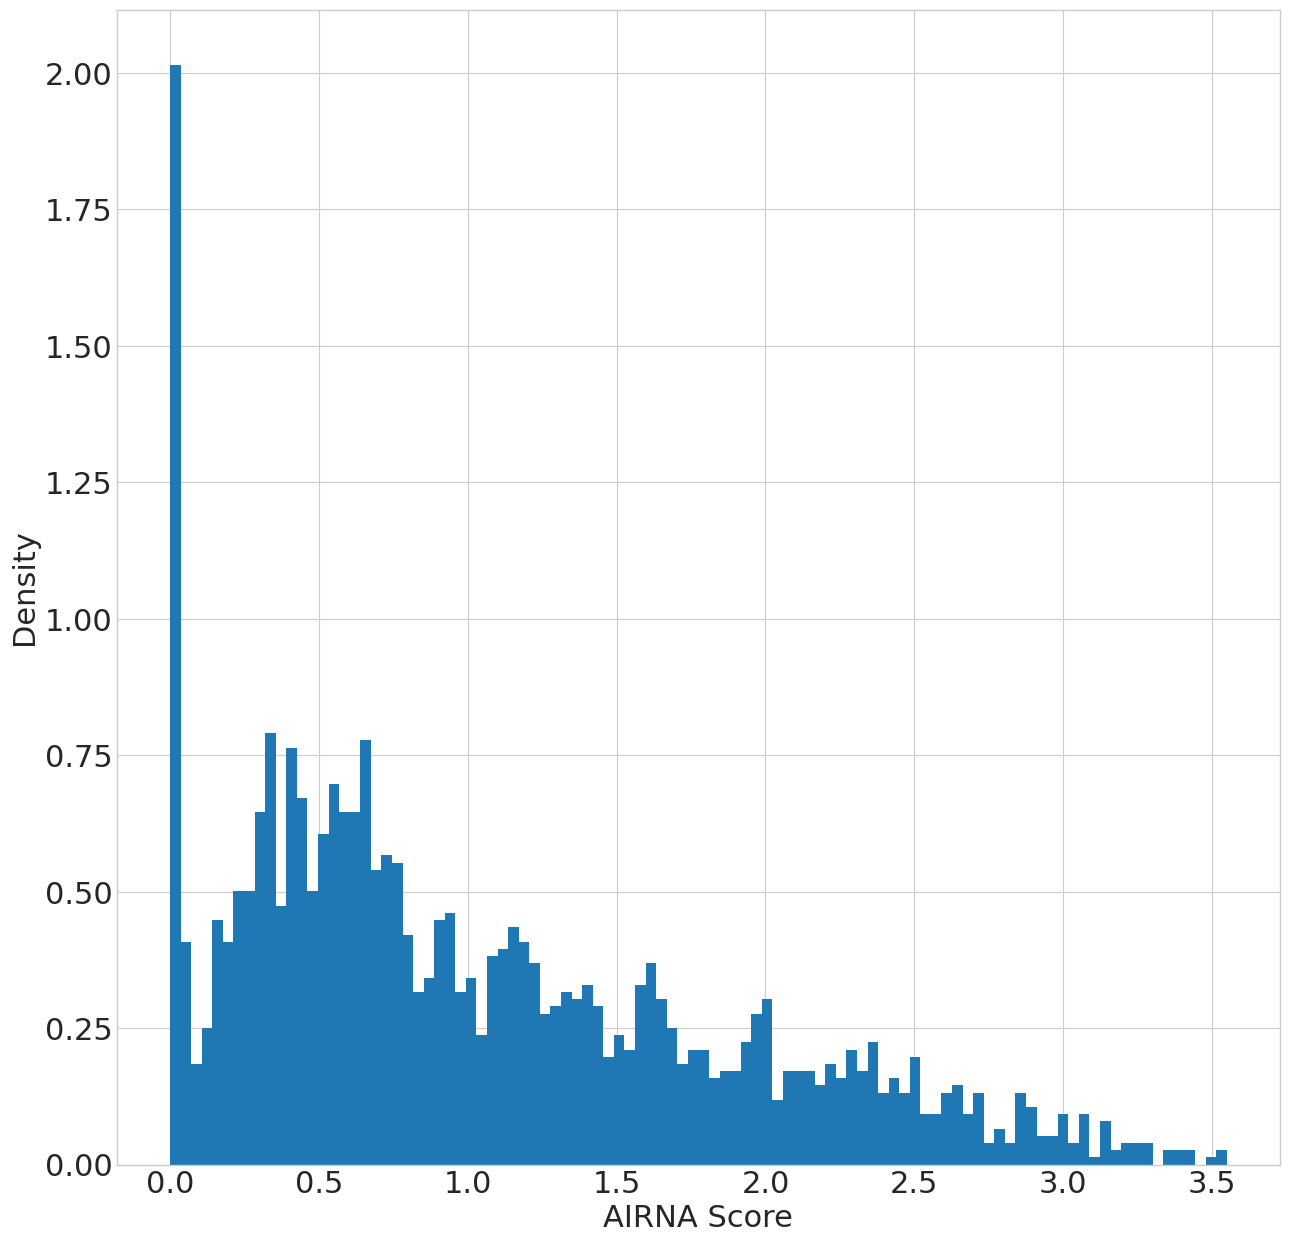

In [68]:
## Predicted pm6a histogram
fig, ax = plt.subplots(1, 1, figsize=(15,15))
gt_df["pm6a_pos_dom_v2"].hist(bins=100, ax=ax, density=True, label="All")
ax.set_xlabel("AIRNA Score")
ax.set_ylabel("Density")
plt.show()

In [28]:
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

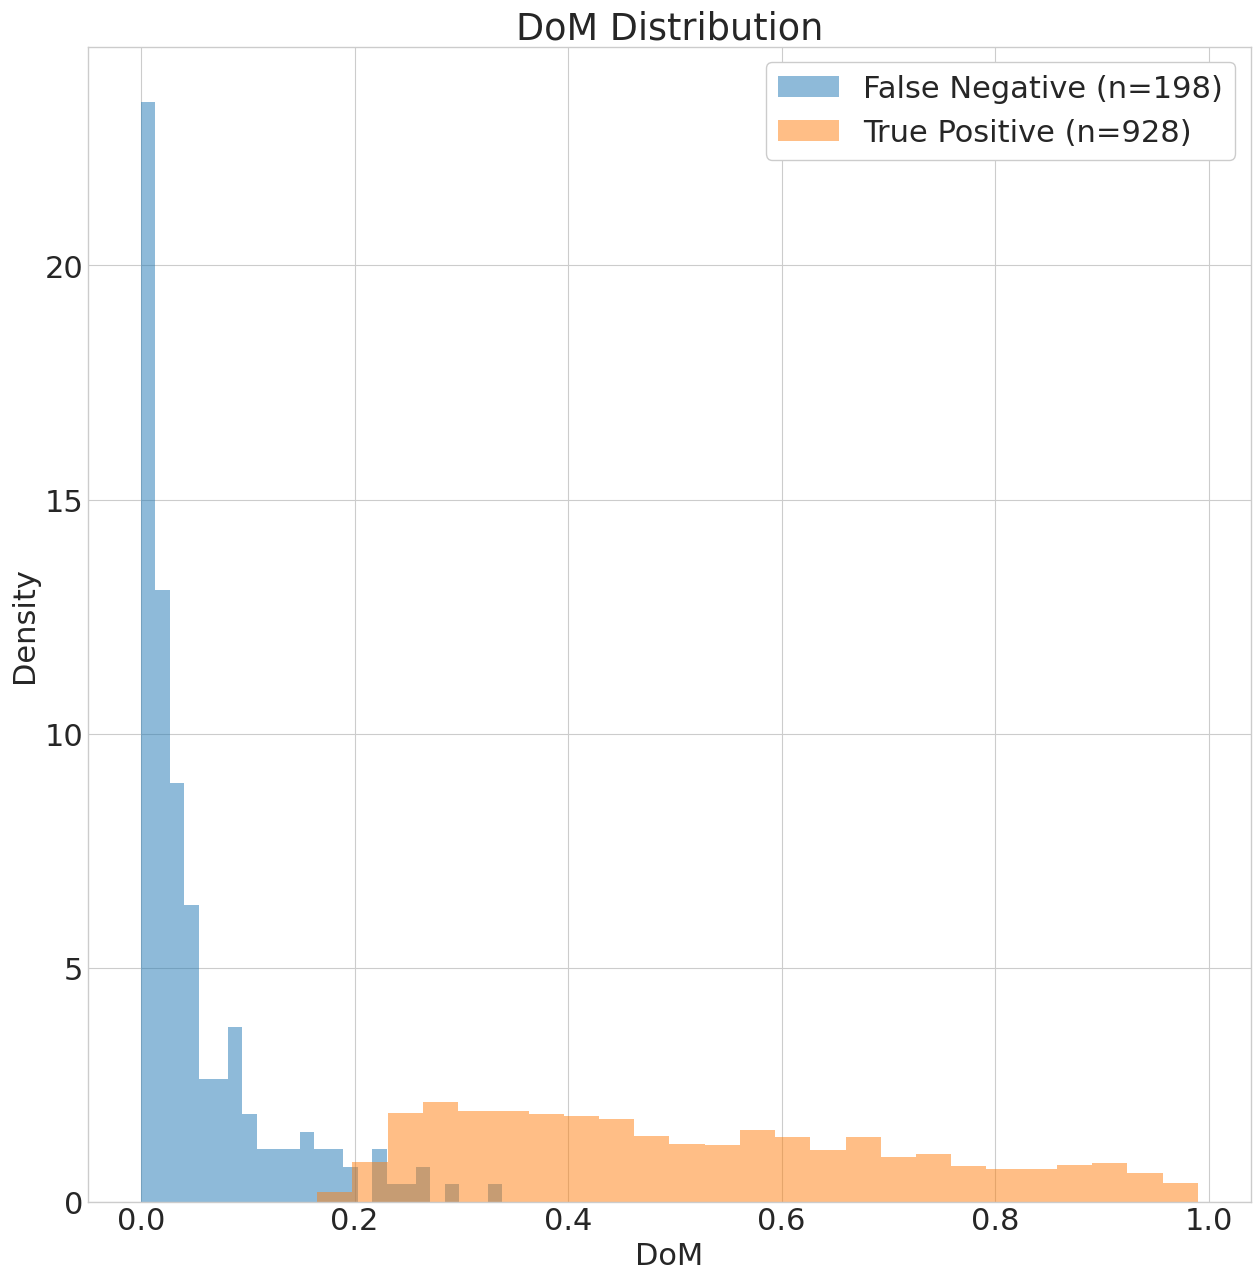

In [58]:
## Plot DoM distribution
fig, ax = plt.subplots(1, 1, figsize=(15,15))
fn_df["dom"].hist(bins=25, ax=ax, density=True, alpha=0.5, label=f"False Negative (n={len(fn_df)})")
tp_df["dom"].hist(bins=25, ax=ax, density=True, alpha=0.5, label=f"True Positive (n={len(tp_df)})")
ax.set_xlabel("DoM")
ax.set_ylabel("Density")
ax.set_title("DoM Distribution")
ax.legend(loc="upper right")
plt.show()

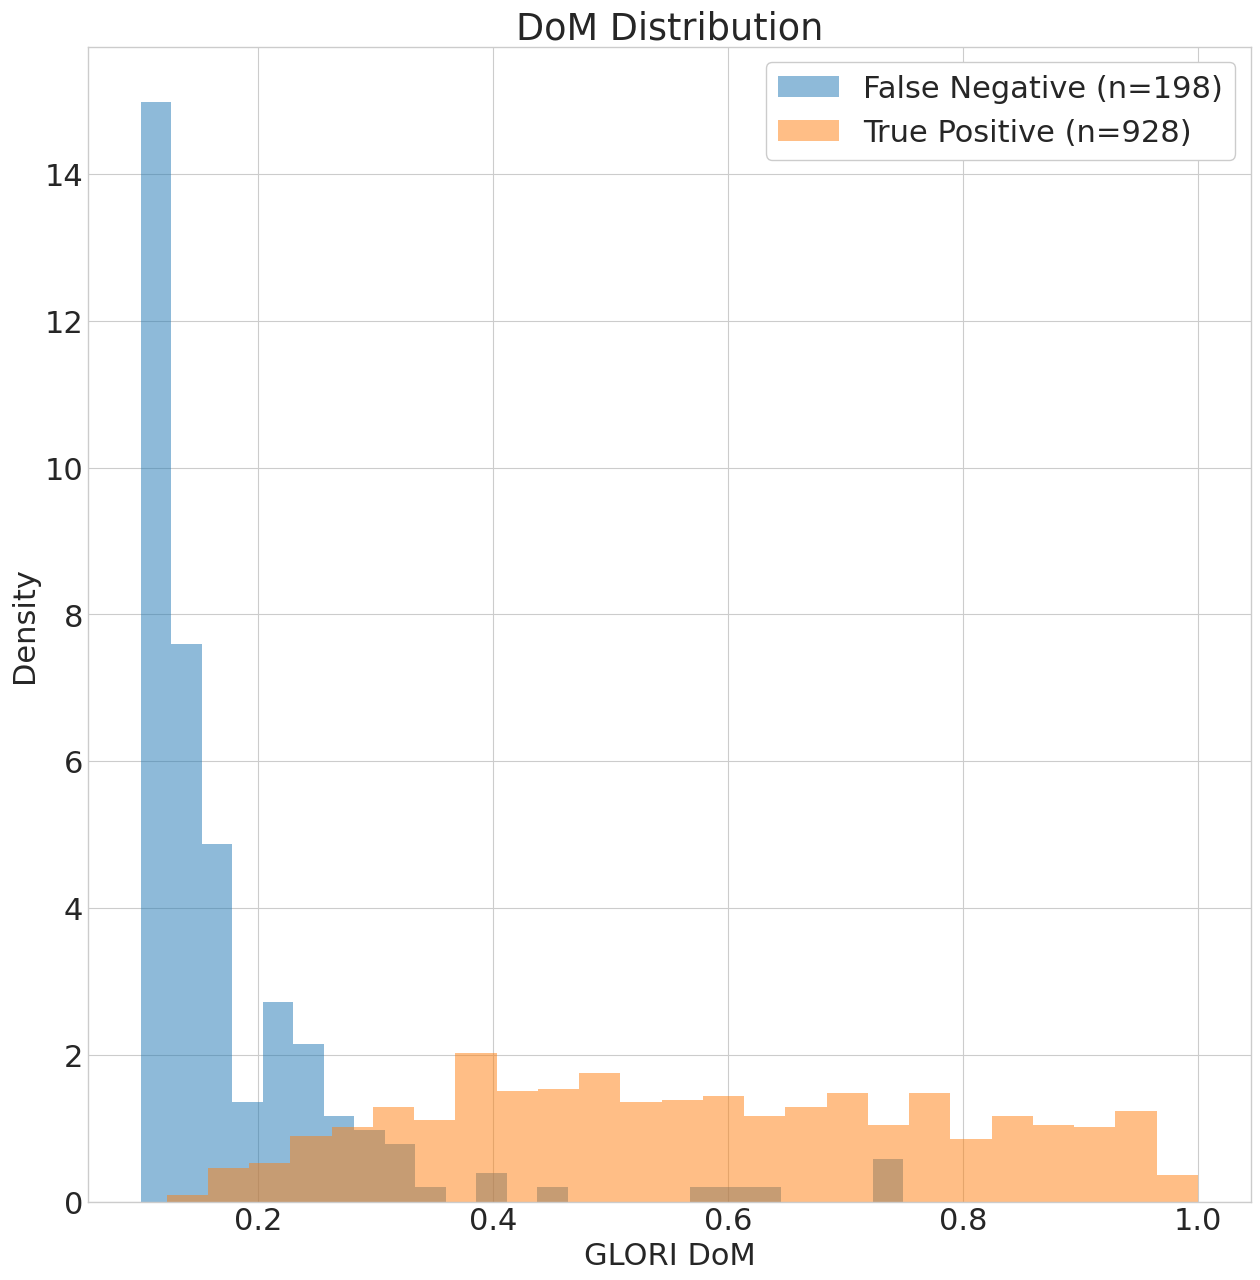

In [59]:
## Plot DoM distribution
fig, ax = plt.subplots(1, 1, figsize=(15,15))
fn_df["dom_label"].hist(bins=25, ax=ax, density=True, alpha=0.5, label=f"False Negative (n={len(fn_df)})")
tp_df["dom_label"].hist(bins=25, ax=ax, density=True, alpha=0.5, label=f"True Positive (n={len(tp_df)})")
ax.set_xlabel("GLORI DoM")
ax.set_ylabel("Density")
ax.set_title("DoM Distribution")
ax.legend(loc="upper right")
plt.show()

In [ ]:
logsum_df = logsum_df.merge(label_df_filtered[["label_id", "index"]], on="label_id", how="inner")

In [30]:
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

gt_df = selected_df[(selected_df["label"]==1)].copy()
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_ids = fn_df["index"].values
tp_ids = tp_df["index"].values

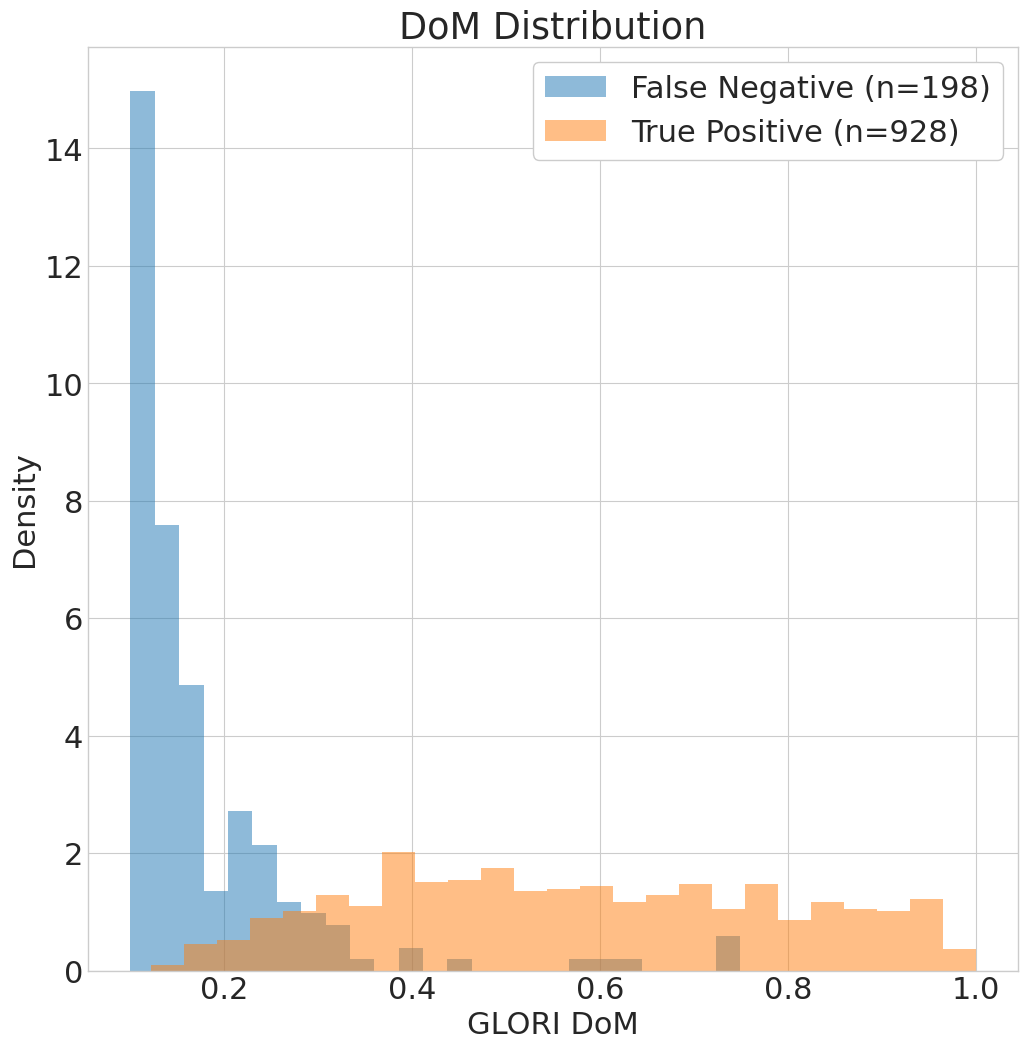

In [31]:
## Plot DoM distribution
fig, ax = plt.subplots(1, 1, figsize=(12,12))
fn_df["dom_label"].hist(bins=25, ax=ax, density=True, alpha=0.5, label=f"False Negative (n={len(fn_df)})")
tp_df["dom_label"].hist(bins=25, ax=ax, density=True, alpha=0.5, label=f"True Positive (n={len(tp_df)})")
ax.set_xlabel("GLORI DoM")
ax.set_ylabel("Density")
ax.set_title("DoM Distribution")
ax.legend(loc="upper right")
plt.show()

In [32]:

gt_df = selected_df[(selected_df["label"]==1)].copy()
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_ids = fn_df["index"].values
tp_ids = tp_df["index"].values

fn_bool_idx = np.isin(pos_data["label_id"], fn_ids)
tp_bool_idx = np.isin(pos_data["label_id"], tp_ids)

fn_data = {key: pos_data[key][fn_bool_idx] for key in pos_data.keys()}
tp_data = {key: pos_data[key][tp_bool_idx] for key in pos_data.keys()}


In [23]:
## Plot Sequence Logo using stacked line plot
nuc_dict = {ord(x):x for x in "ACGT"}

def get_nuc_frac_per_pos(seq_arr):
    seq_len = seq_arr.shape[1]
    seq_frac_list = np.array([[np.count_nonzero(seq_arr[:,i] == x) for x in nuc_dict] for i in range(seq_len)])
    seq_frac_list = seq_frac_list / seq_frac_list.sum(axis=1, keepdims=True)
    return seq_frac_list


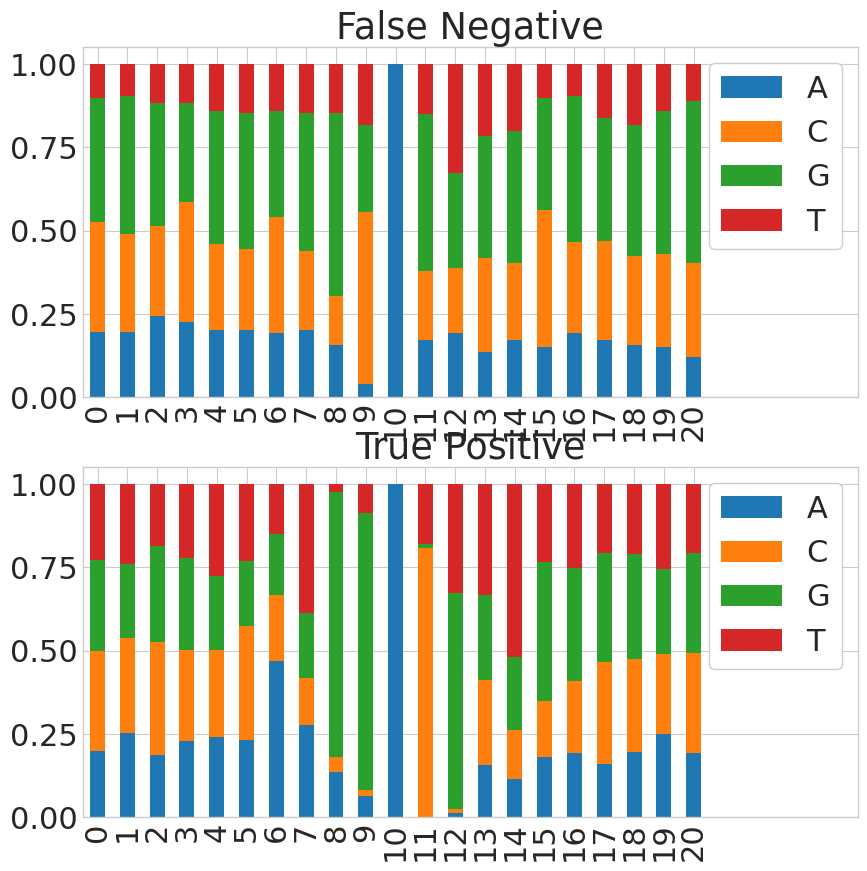

In [33]:
## Get first occurence of each id in data
fn_first_idx = np.unique(fn_data["label_id_str"], return_index=True)[1]
tp_first_idx = np.unique(tp_data["label_id_str"], return_index=True)[1]

fn_data = {key: fn_data[key][fn_first_idx] for key in fn_data.keys()}
tp_data = {key: tp_data[key][tp_first_idx] for key in tp_data.keys()}

fn_nuc = get_nuc_frac_per_pos(fn_data["kmer_token"])
tp_nuc = get_nuc_frac_per_pos(tp_data["kmer_token"])

fn_nuc = pd.DataFrame(fn_nuc, columns=["A", "C", "G", "T"])
tp_nuc = pd.DataFrame(tp_nuc, columns=["A", "C", "G", "T"])


## Plot stacked bar
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fn_nuc.plot(kind="bar", stacked=True, ax=axes[0], legend="upper right")
tp_nuc.plot(kind="bar", stacked=True, ax=axes[1], legend="upper right")
axes[0].set_title("False Negative")
axes[1].set_title("True Positive")
axes[0].set_xlim(-0.5,25.5)
axes[1].set_xlim(-0.5,25.5)
plt.show()


In [13]:
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

gt_df = selected_df[(selected_df["label"]==1)].copy()

fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_ids = fn_df["index"].values
tp_ids = tp_df["index"].values

fn_bool_idx = np.isin(pos_data["label_id"], fn_ids)
tp_bool_idx = np.isin(pos_data["label_id"], tp_ids)

fn_data = {key: pos_data[key][fn_bool_idx] for key in pos_data.keys()}
tp_data = {key: pos_data[key][tp_bool_idx] for key in pos_data.keys()}



In [50]:
motif_arr = ["".join([chr(y) for y in x]) for x in tss_data["kmer_token"]]
tss_data["motif"] = np.array(motif_arr)
tss_data["5mer"] = np.array([x[8:13] for x in tss_data["motif"]])


In [53]:
tss_data["5mer"] = np.array([x[8:13] for x in tss_data["motif"]])

[[11 10 10 ... 26 24 20]
 [23 23 23 ... 25 23 26]
 [26 26 27 ... 38 43 47]
 ...
 [26 26 20 ... 34 32 31]
 [20 23 25 ... 26 26 27]
 [26 26 30 ... 16 15 15]]


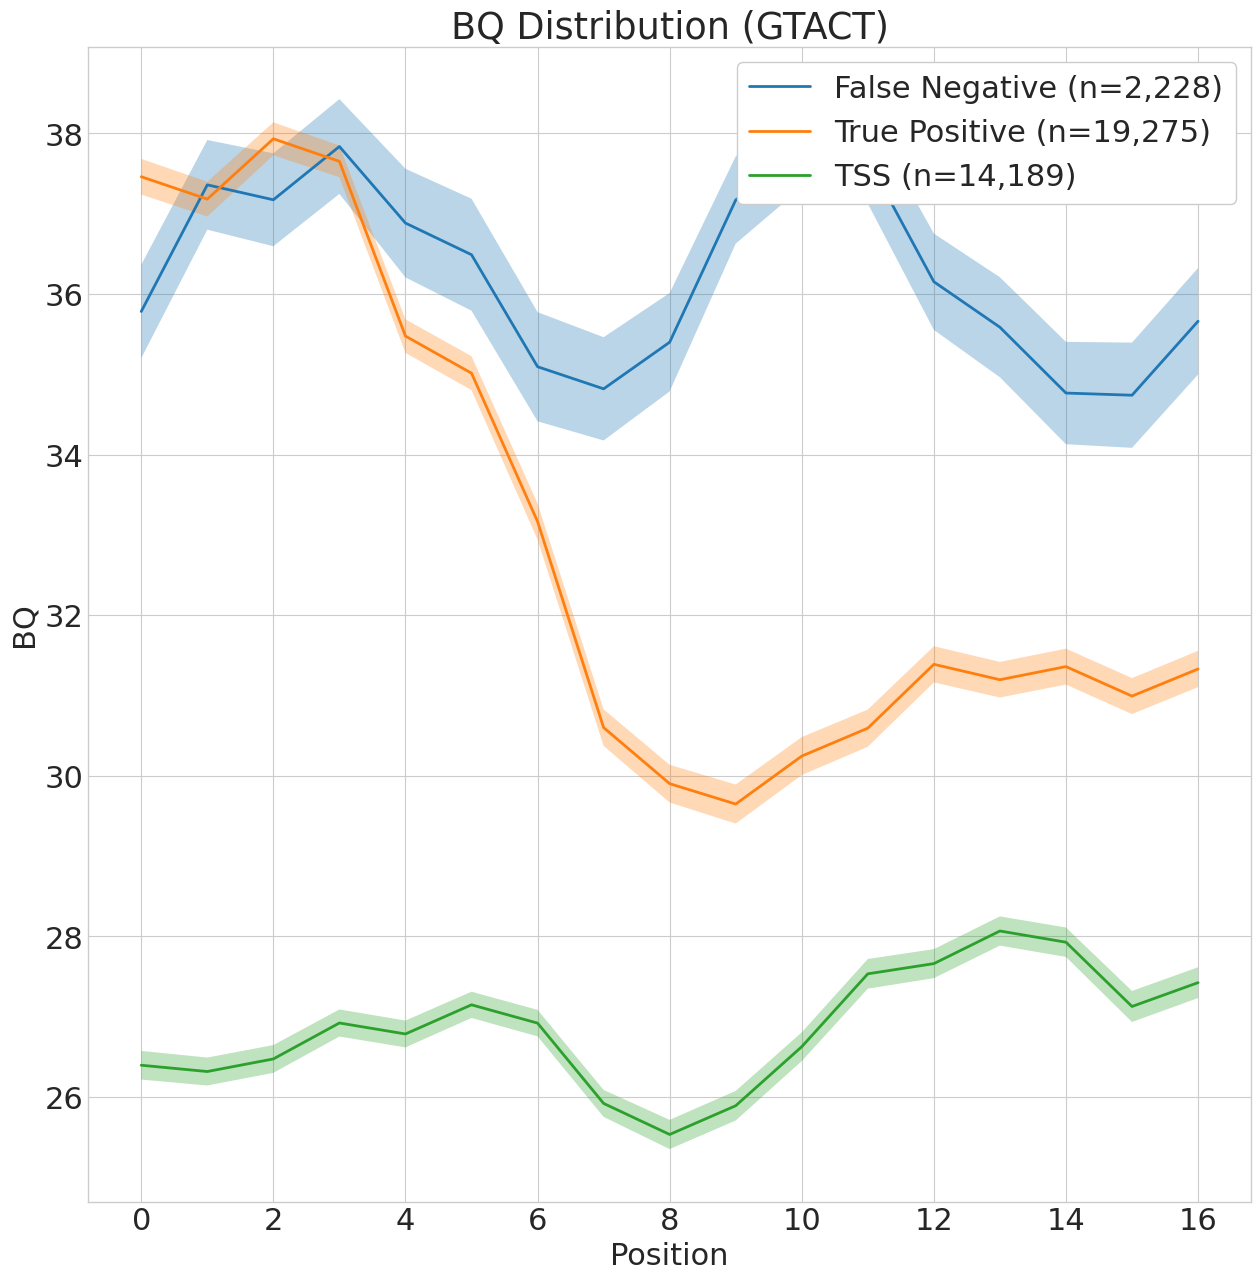

In [72]:
## Get BQ distribution
motif = "GTACT"


tn_bool_idx = tss_data["5mer"] == motif
tn_data = {key: tss_data[key][tn_bool_idx] for key in tss_data.keys()}
tn_bq = tn_data["bq_token"]

print(tn_bq)


motif_df = gt_df[gt_df["5mer"] == motif].copy()
fn_df = motif_df[motif_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = motif_df[motif_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_ids = fn_df["index"].values
tp_ids = tp_df["index"].values

fn_bool_idx = np.isin(pos_data["label_id"], fn_ids)
tp_bool_idx = np.isin(pos_data["label_id"], tp_ids)

fn_data = {key: pos_data[key][fn_bool_idx] for key in pos_data.keys()}
tp_data = {key: pos_data[key][tp_bool_idx] for key in pos_data.keys()}


fn_bq = fn_data["bq_token"]
tp_bq = tp_data["bq_token"]


mean_fn_bq = fn_bq.mean(axis=0)
std_fn_bq = fn_bq.std(axis=0)
ci_fn_bq = 2.58*std_fn_bq/np.sqrt(fn_bq.shape[0])

mean_tp_bq = tp_bq.mean(axis=0)
std_tp_bq = tp_bq.std(axis=0)
ci_tp_bq = 2.58*std_tp_bq/np.sqrt(tp_bq.shape[0])

mean_tn_bq = tn_bq.mean(axis=0)
std_tn_bq = tn_bq.std(axis=0)
ci_tn_bq = 2.58*std_tn_bq/np.sqrt(tn_bq.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(15,15))
ax.plot(mean_fn_bq, label=f"False Negative (n={fn_bq.shape[0]:,})")
ax.fill_between(np.arange(len(mean_fn_bq)), mean_fn_bq-ci_fn_bq, mean_fn_bq+ci_fn_bq, alpha=0.3)
ax.plot(mean_tp_bq, label=f"True Positive (n={tp_bq.shape[0]:,})")
ax.fill_between(np.arange(len(mean_tp_bq)), mean_tp_bq-ci_tp_bq, mean_tp_bq+ci_tp_bq, alpha=0.3)
ax.plot(mean_tn_bq, label=f"TSS (n={tn_bq.shape[0]:,})")
ax.fill_between(np.arange(len(mean_tn_bq)), mean_tn_bq-ci_tn_bq, mean_tn_bq+ci_tn_bq, alpha=0.3)

ax.set_xlabel("Position")
ax.set_ylabel(f"BQ")
ax.set_title(f"BQ Distribution ({motif})")
ax.legend(loc="upper right")



In [67]:

fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()
fn_df["5mer"].value_counts()

5mer
GGACG    477
GGATT    142
AGACG     75
GTACT     53
GAACG     35
CGACT     27
ATACT     18
AGATT     18
CAACT     15
GCACT     13
TGACG      9
GGATG      6
GAATT      6
GGATA      5
TTACT      5
AAACG      4
CTACT      4
GGAGT      4
ACACT      3
GGATC      2
GGAAT      1
ATACA      1
GGAGC      1
AGAGT      1
GTACC      1
GTACA      1
GGAGG      1
Name: count, dtype: int64

[[29 30 31 ... 30 30 30]
 [49 48 37 ... 38 39 45]
 [21 18 18 ... 16 11 10]
 ...
 [18 17 17 ... 36 37 37]
 [37 24 23 ... 18 18 17]
 [39 38 35 ... 29 32 32]]


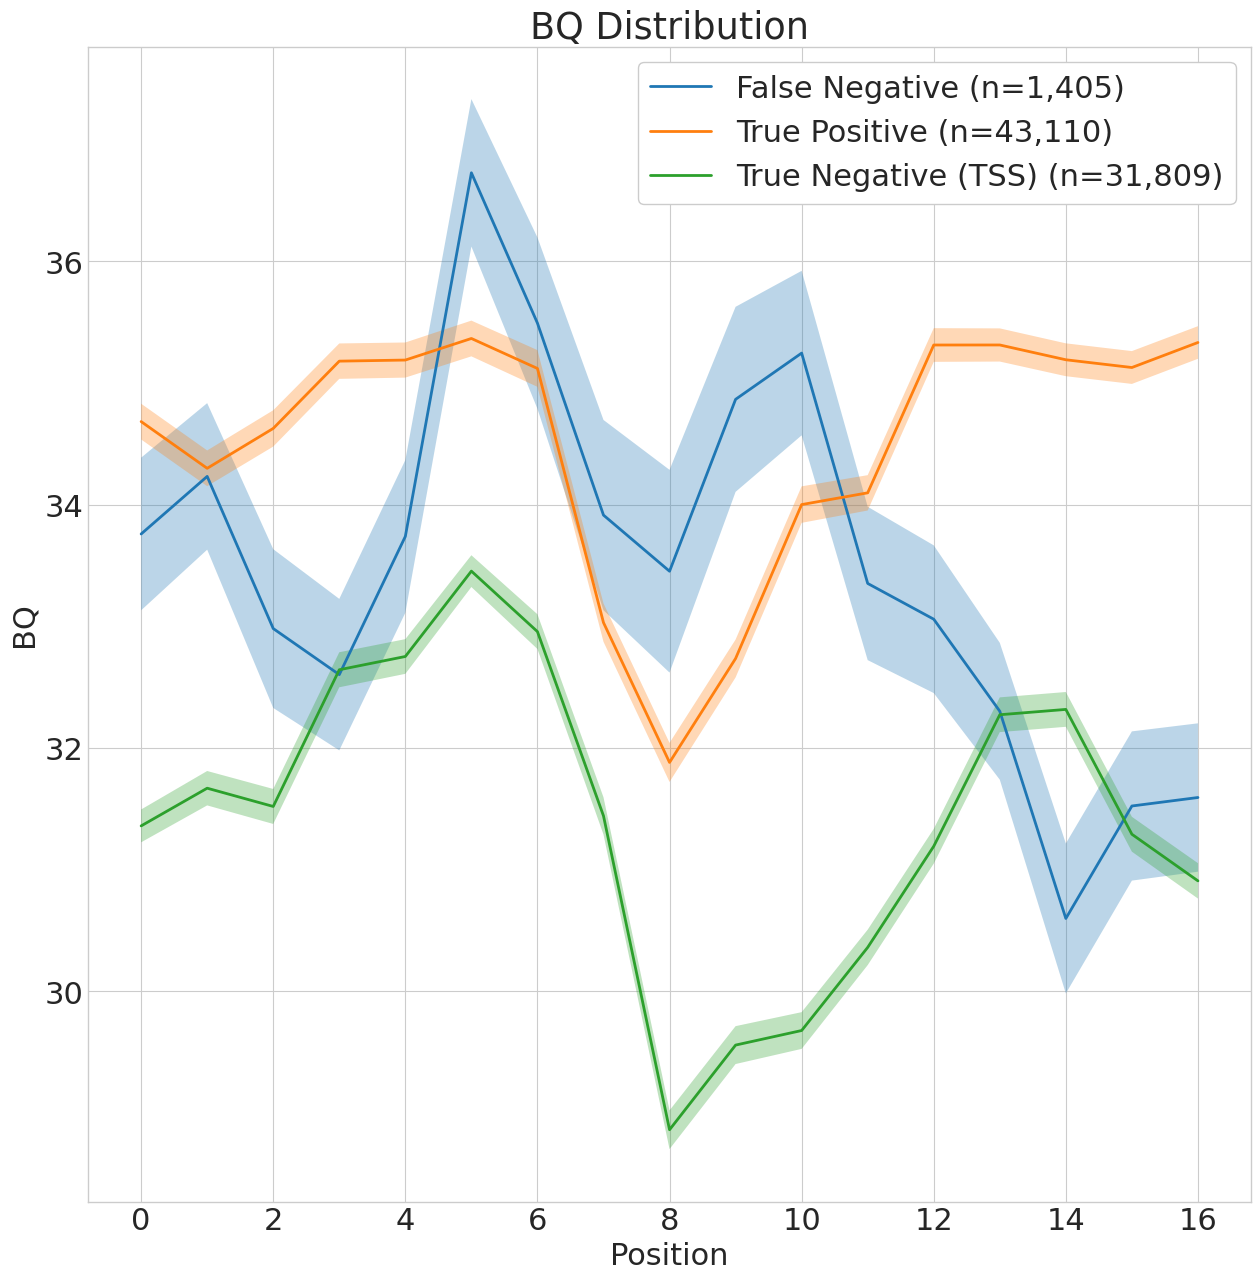

In [57]:
## Get BQ distribution

tn_bool_idx = tss_data["5mer"] == "GGATT"
tn_data = {key: tss_data[key][tn_bool_idx] for key in tss_data.keys()}
tn_bq = tn_data["bq_token"]

print(tn_bq)


motif_df = gt_df[gt_df["5mer"] == "GGATT"].copy()
fn_df = motif_df[motif_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = motif_df[motif_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_ids = fn_df["index"].values
tp_ids = tp_df["index"].values

fn_bool_idx = np.isin(pos_data["label_id"], fn_ids)
tp_bool_idx = np.isin(pos_data["label_id"], tp_ids)

fn_data = {key: pos_data[key][fn_bool_idx] for key in pos_data.keys()}
tp_data = {key: pos_data[key][tp_bool_idx] for key in pos_data.keys()}


fn_bq = fn_data["bq_token"]
tp_bq = tp_data["bq_token"]


mean_fn_bq = fn_bq.mean(axis=0)
std_fn_bq = fn_bq.std(axis=0)
ci_fn_bq = 2.58*std_fn_bq/np.sqrt(fn_bq.shape[0])

mean_tp_bq = tp_bq.mean(axis=0)
std_tp_bq = tp_bq.std(axis=0)
ci_tp_bq = 2.58*std_tp_bq/np.sqrt(tp_bq.shape[0])

mean_tn_bq = tn_bq.mean(axis=0)
std_tn_bq = tn_bq.std(axis=0)
ci_tn_bq = 2.58*std_tn_bq/np.sqrt(tn_bq.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(15,15))
ax.plot(mean_fn_bq, label=f"False Negative (n={fn_bq.shape[0]:,})")
ax.fill_between(np.arange(len(mean_fn_bq)), mean_fn_bq-ci_fn_bq, mean_fn_bq+ci_fn_bq, alpha=0.3)
ax.plot(mean_tp_bq, label=f"True Positive (n={tp_bq.shape[0]:,})")
ax.fill_between(np.arange(len(mean_tp_bq)), mean_tp_bq-ci_tp_bq, mean_tp_bq+ci_tp_bq, alpha=0.3)
ax.plot(mean_tn_bq, label=f"True Negative (TSS) (n={tn_bq.shape[0]:,})")
ax.fill_between(np.arange(len(mean_tn_bq)), mean_tn_bq-ci_tn_bq, mean_tn_bq+ci_tn_bq, alpha=0.3)

ax.set_xlabel("Position")
ax.set_ylabel("BQ")
ax.set_title("BQ Distribution")
ax.legend(loc="upper right")



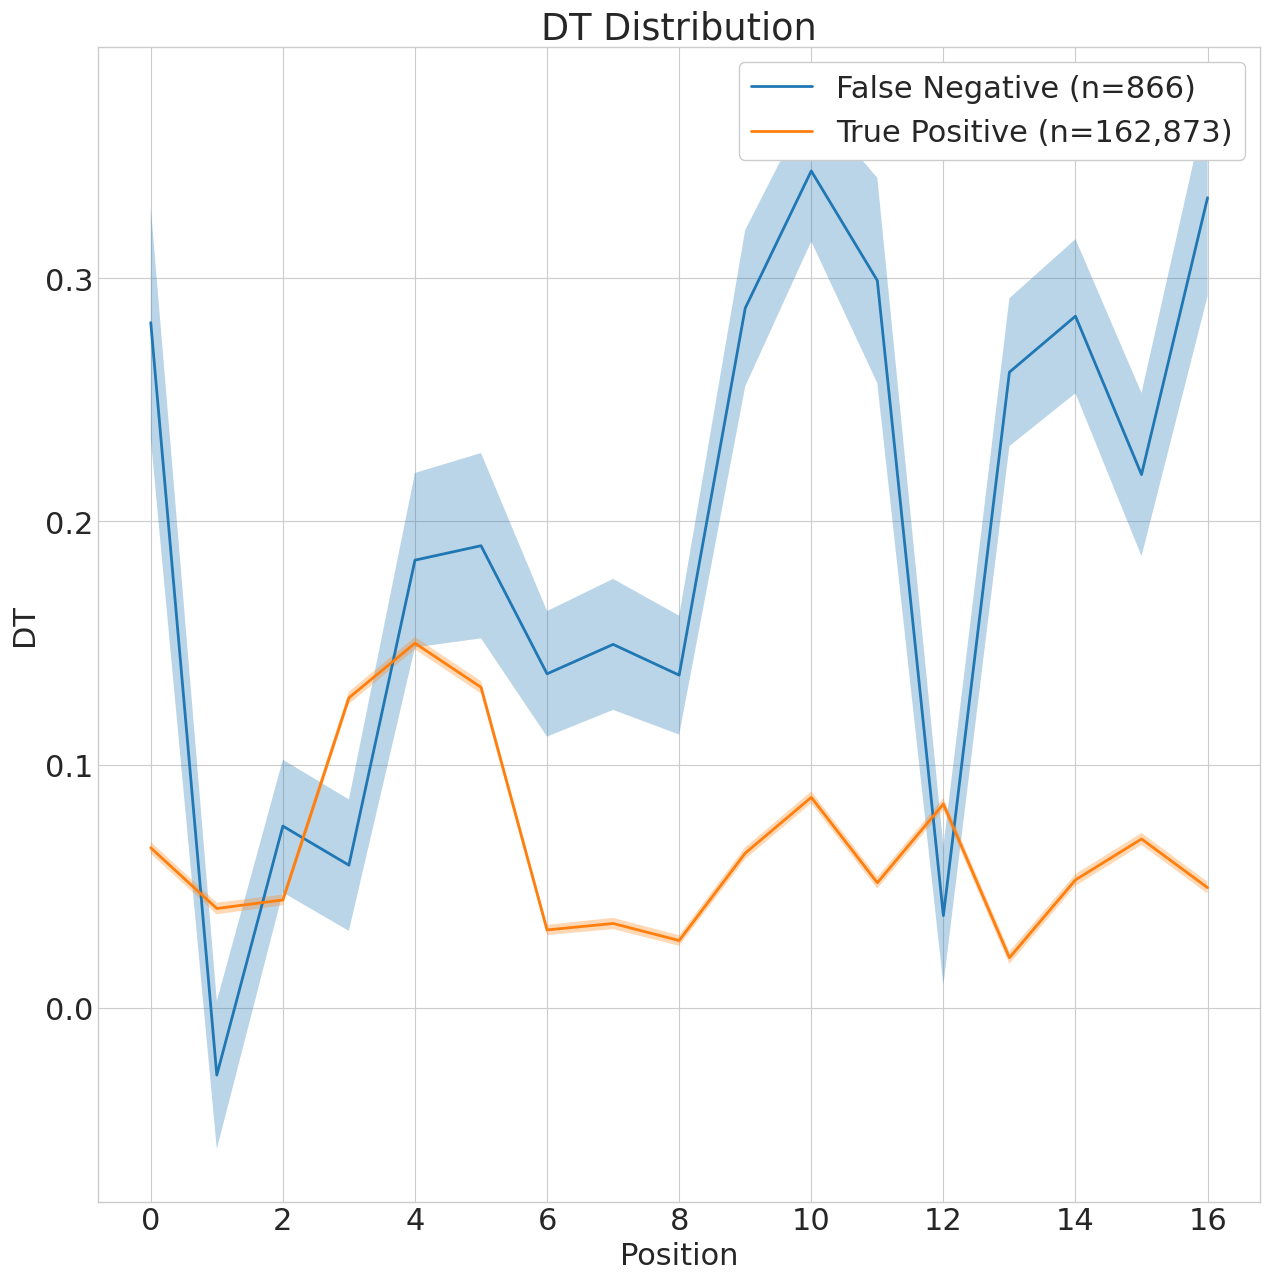

In [37]:
## Get BQ distribution
motif_df = gt_df[gt_df["5mer"] == "GGACG"].copy()
fn_df = motif_df[motif_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = motif_df[motif_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_ids = fn_df["index"].values
tp_ids = tp_df["index"].values

fn_bool_idx = np.isin(pos_data["label_id"], fn_ids)
tp_bool_idx = np.isin(pos_data["label_id"], tp_ids)

fn_data = {key: pos_data[key][fn_bool_idx] for key in pos_data.keys()}
tp_data = {key: pos_data[key][tp_bool_idx] for key in pos_data.keys()}


fn_bq = fn_data["dwell_motor_token"]
tp_bq = tp_data["dwell_motor_token"]


mean_fn_bq = fn_bq.mean(axis=0)
std_fn_bq = fn_bq.std(axis=0)
ci_fn_bq = 2.58*std_fn_bq/np.sqrt(fn_bq.shape[0])

mean_tp_bq = tp_bq.mean(axis=0)
std_tp_bq = tp_bq.std(axis=0)
ci_tp_bq = 2.58*std_tp_bq/np.sqrt(tp_bq.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(15,15))
ax.plot(mean_fn_bq, label=f"False Negative (n={fn_bq.shape[0]:,})")
ax.fill_between(np.arange(len(mean_fn_bq)), mean_fn_bq-ci_fn_bq, mean_fn_bq+ci_fn_bq, alpha=0.3)
ax.plot(mean_tp_bq, label=f"True Positive (n={tp_bq.shape[0]:,})")
ax.fill_between(np.arange(len(mean_tp_bq)), mean_tp_bq-ci_tp_bq, mean_tp_bq+ci_tp_bq, alpha=0.3)

ax.set_xlabel("Position")
ax.set_ylabel("DT")
ax.set_title("DT Distribution")
ax.legend(loc="upper right")

In [24]:
## Get BQ distribution 

def get_signal_data(data_dict):
    segment_len_arr = np.cumsum(data_dict["segment_len_arr"], axis = 1) * 6
    segment_slices = np.array([np.mean(data_dict["signal_token"][i,segment_len_arr[i,7]:segment_len_arr[i,8]])  for i in range(len(data_dict["signal_token"]))])
    return segment_slices

fn_signal = get_signal_data(fn_data)
tp_signal = get_signal_data(tp_data)

print(fn_signal)
print(tp_signal)

[-0.557087    0.9892786   1.6965173  ...  1.5816479  -0.16386808
 -0.3993513 ]
[-0.96557945 -0.9129638  -0.61115766 ... -0.2622815  -0.00984178
 -0.9623821 ]


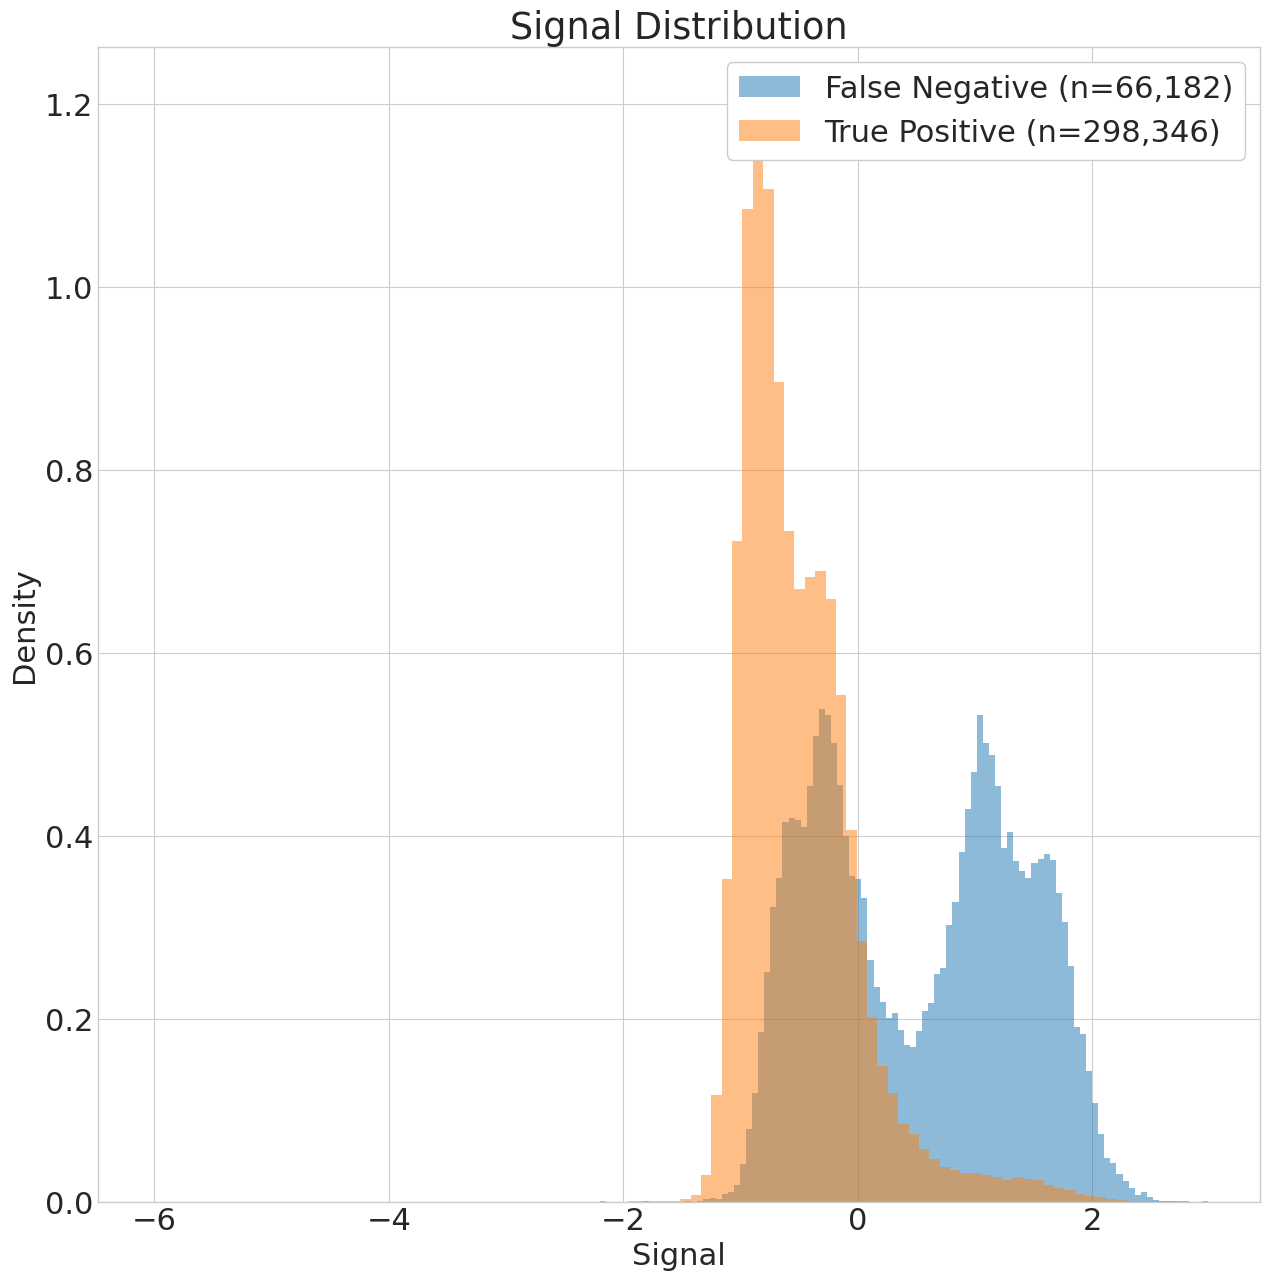

In [25]:
## Plot Histogram
fig, ax = plt.subplots(1, 1, figsize=(15,15))
ax.hist(fn_signal, bins=100, alpha=0.5, label=f"False Negative (n={fn_signal.shape[0]:,})", density=True)
ax.hist(tp_signal, bins=100, alpha=0.5, label=f"True Positive (n={tp_signal.shape[0]:,})", density=True)
ax.set_xlabel("Signal")
ax.set_ylabel("Density")
ax.set_title("Signal Distribution")
ax.legend(loc="upper right")
plt.show()

In [37]:
## Breakdown by trimer
## Get BQ distribution 
fn_data["kmer_token"] = fn_data["kmer_token"].astype(np.int32)
tp_data["kmer_token"] = tp_data["kmer_token"].astype(np.int32)

fn_trimer_arr = fn_data["kmer_token"][:,9]*1000 + fn_data["kmer_token"][:,11]
tp_trimer_arr = tp_data["kmer_token"][:,9]*1000 + tp_data["kmer_token"][:,11]

print(fn_trimer_arr)
print(tp_trimer_arr)

[71065 71065 84071 ... 67071 71065 67067]
[71067 71067 71067 ... 71084 71067 71084]


In [38]:
nuc_dict = {ord(x):x for x in "ACGT"}

fn_signal_dict = {}
tp_signal_dict = {}

for front in nuc_dict:
    for back in nuc_dict:
        seq = f"{nuc_dict[front]}A{nuc_dict[back]}"
        trimer = front * 1000 + back
        fn_signal_dict[seq] = fn_signal[(fn_trimer_arr == trimer)]
        tp_signal_dict[seq] = tp_signal[(tp_trimer_arr == trimer)]

print(fn_signal_dict)
        

{'AAA': array([ 2.56356597e-03, -4.27305222e-01,  1.30989361e+00,  1.05517888e+00,
        1.11845315e+00,  1.32491744e+00,  1.04401720e+00,  1.04744065e+00,
       -2.36153509e-02,  1.10704195e+00,  1.16539669e+00,  7.59514188e-03,
       -1.69998229e-01,  7.12225020e-01, -2.39379272e-01, -3.04524988e-01,
        1.06790626e+00,  1.96117342e-01,  1.28716338e+00,  1.66865599e+00,
       -2.27462500e-02,  9.01874542e-01,  1.01236689e+00,  1.59643686e+00,
       -2.92948335e-01, -1.26919702e-01,  1.77526716e-02,  1.32452917e+00,
        2.30639100e+00,  9.13371027e-01,  1.43382132e+00,  7.24616230e-01,
        7.59976864e-01, -3.20582569e-01, -1.25493808e-02, -1.66817918e-01,
       -3.74900818e-01,  8.08314860e-01, -3.48678559e-01,  9.52398717e-01,
        1.58059156e+00,  3.80138725e-01, -3.05007011e-01,  1.72841883e+00,
       -3.65672201e-01, -4.48656917e-01, -1.14612103e-01, -1.45382687e-01,
        1.03117979e+00,  7.28460491e-01,  1.05370986e+00,  8.63416016e-01,
        9.0424162

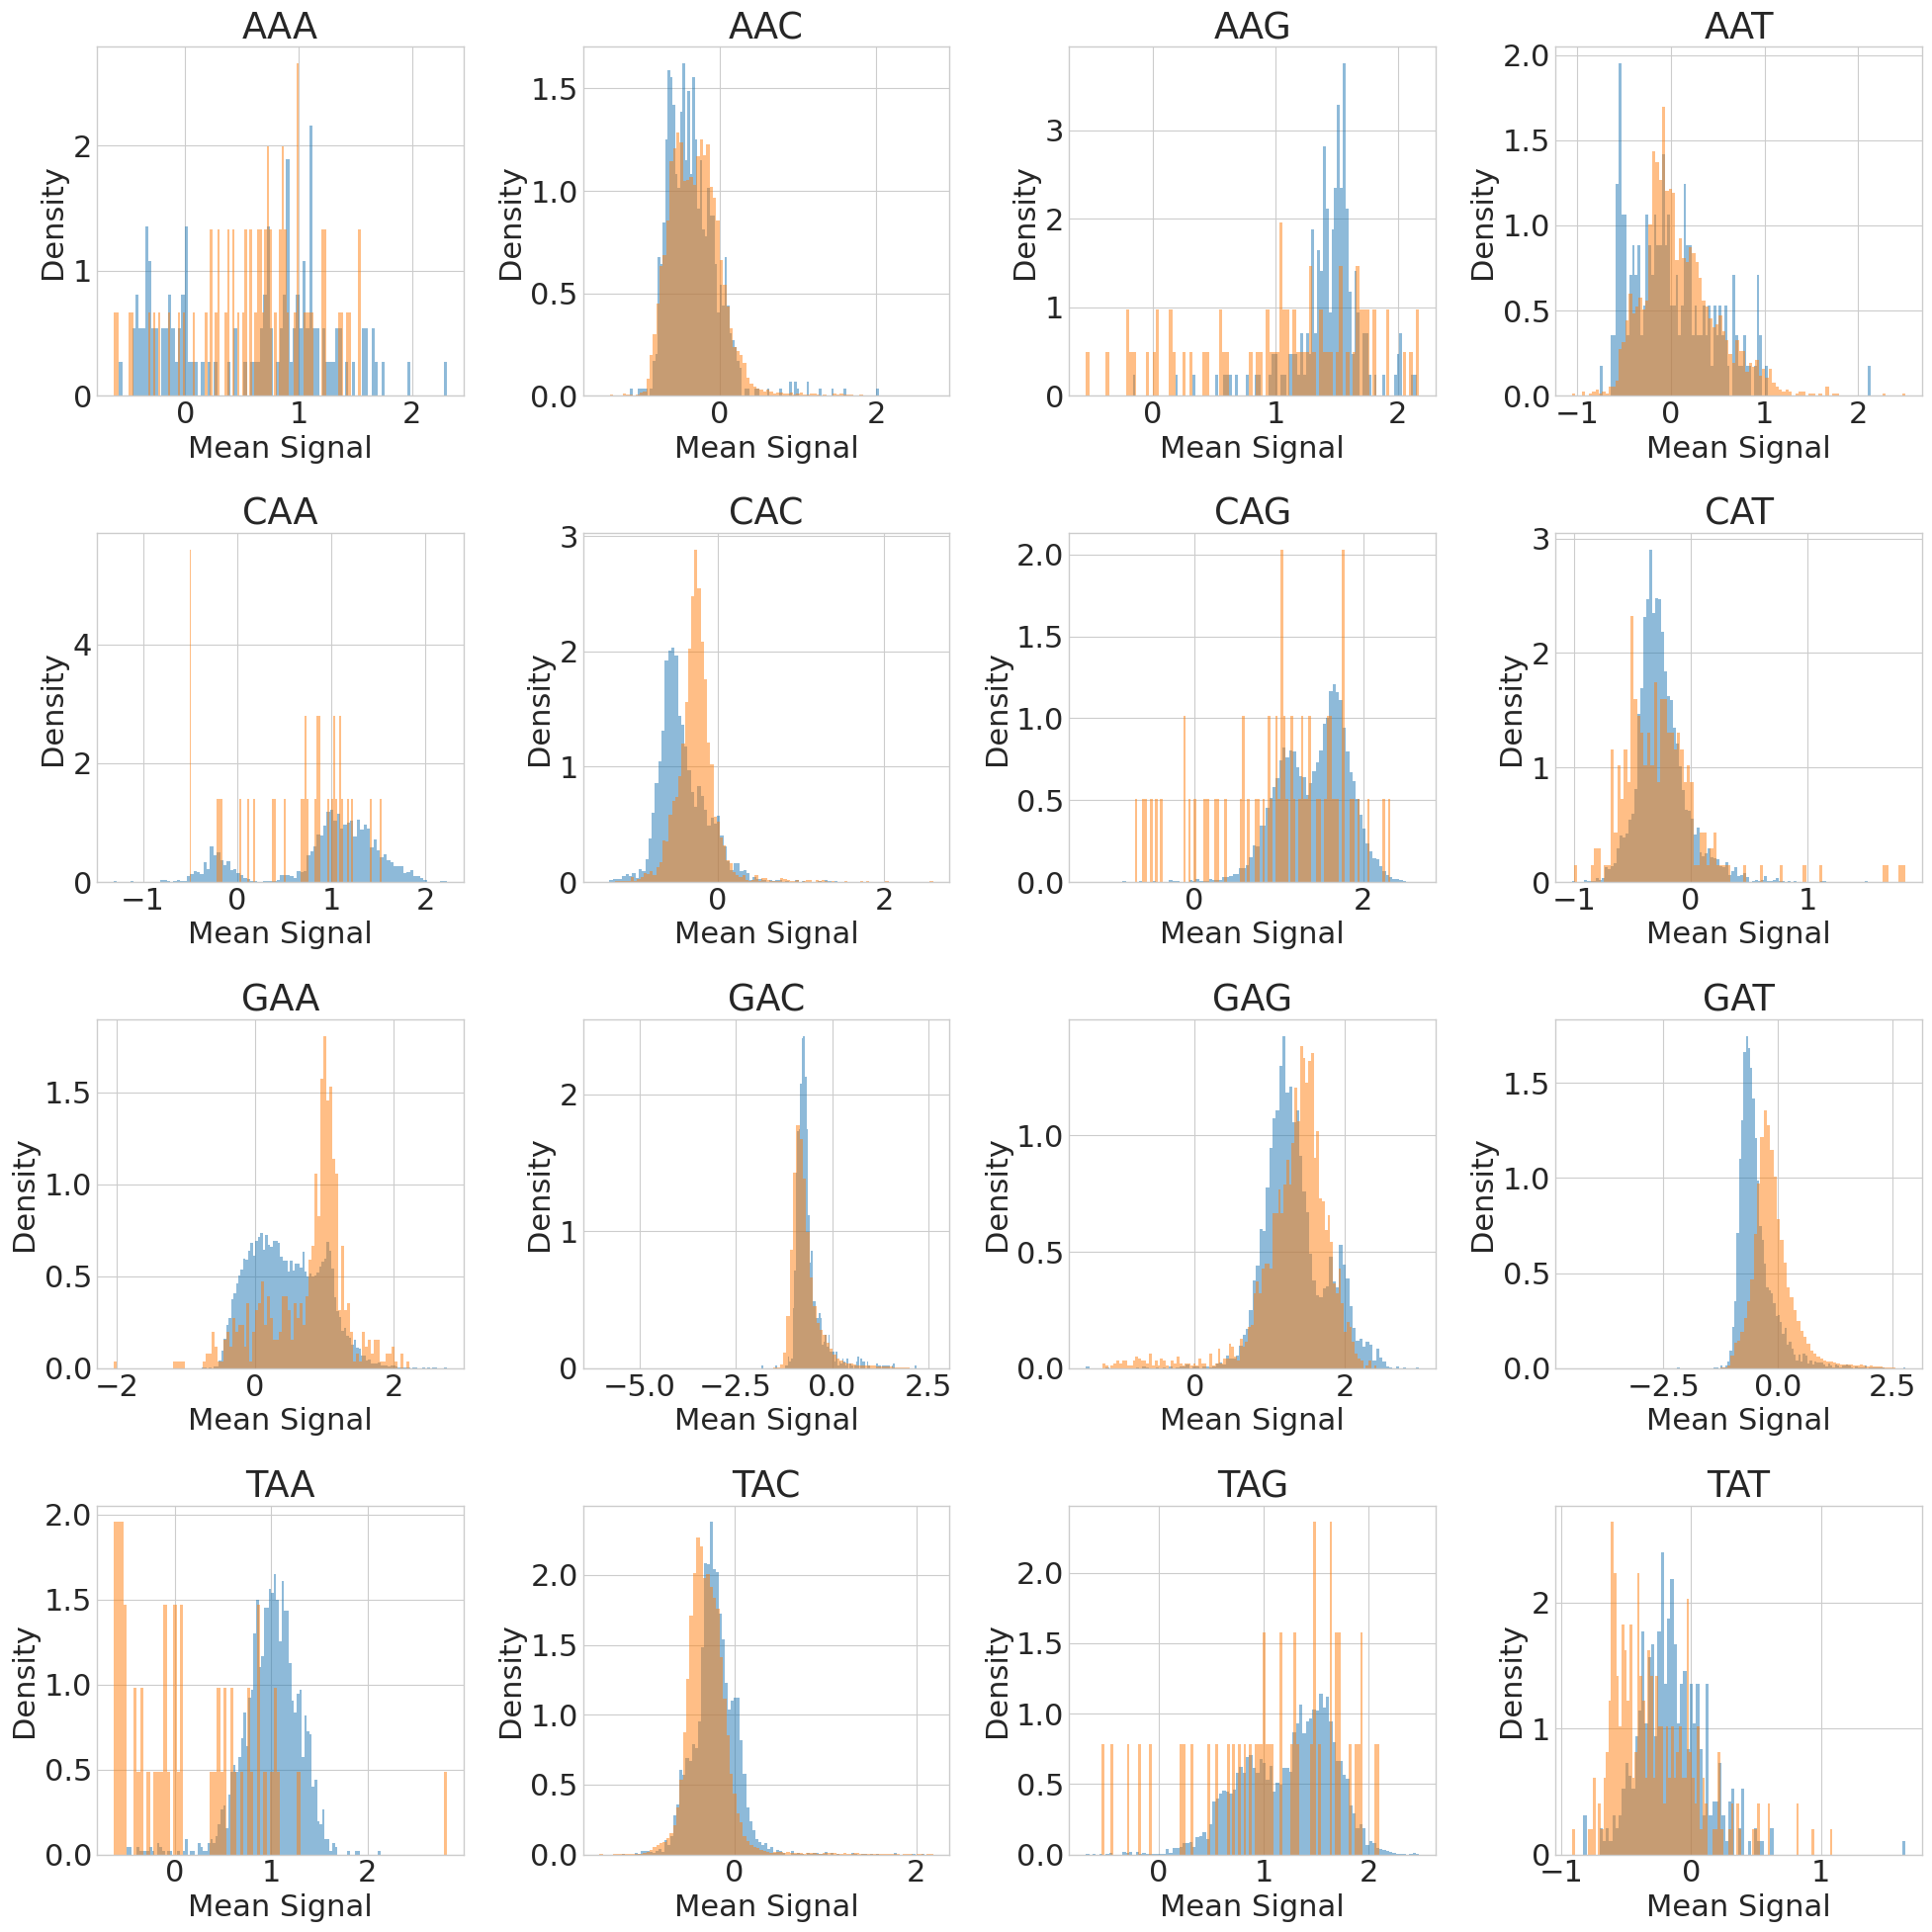

In [46]:
## Plot Histogram
fig, axes = plt.subplots(4, 4, figsize=(20,20))
for i, front in enumerate(nuc_dict):
    for j, back in enumerate(nuc_dict):
        seq = f"{nuc_dict[front]}A{nuc_dict[back]}"
        ax = axes[i,j]
        ax.hist(fn_signal_dict[seq], bins=100, alpha=0.5, label=f"False Negative (n={fn_signal_dict[seq].shape[0]:,})", density=True)
        ax.hist(tp_signal_dict[seq], bins=100, alpha=0.5, label=f"True Positive (n={tp_signal_dict[seq].shape[0]:,})", density=True)
        ax.set_xlabel("Mean Signal")
        ax.set_ylabel("Density")
        ax.set_title(f"{seq}")
fig.tight_layout()
plt.show()

[71065 71065 84071 ... 67071 71065 67067]
[71067 71067 71067 ... 71084 71067 71084]
[71084 65071 71065 ... 67071 67067 84067]
{'AAA': array([ 2.56356597e-03, -4.27305222e-01,  1.30989361e+00,  1.05517888e+00,
        1.11845315e+00,  1.32491744e+00,  1.04401720e+00,  1.04744065e+00,
       -2.36153509e-02,  1.10704195e+00,  1.16539669e+00,  7.59514188e-03,
       -1.69998229e-01,  7.12225020e-01, -2.39379272e-01, -3.04524988e-01,
        1.06790626e+00,  1.96117342e-01,  1.28716338e+00,  1.66865599e+00,
       -2.27462500e-02,  9.01874542e-01,  1.01236689e+00,  1.59643686e+00,
       -2.92948335e-01, -1.26919702e-01,  1.77526716e-02,  1.32452917e+00,
        2.30639100e+00,  9.13371027e-01,  1.43382132e+00,  7.24616230e-01,
        7.59976864e-01, -3.20582569e-01, -1.25493808e-02, -1.66817918e-01,
       -3.74900818e-01,  8.08314860e-01, -3.48678559e-01,  9.52398717e-01,
        1.58059156e+00,  3.80138725e-01, -3.05007011e-01,  1.72841883e+00,
       -3.65672201e-01, -4.48656917e-01, 

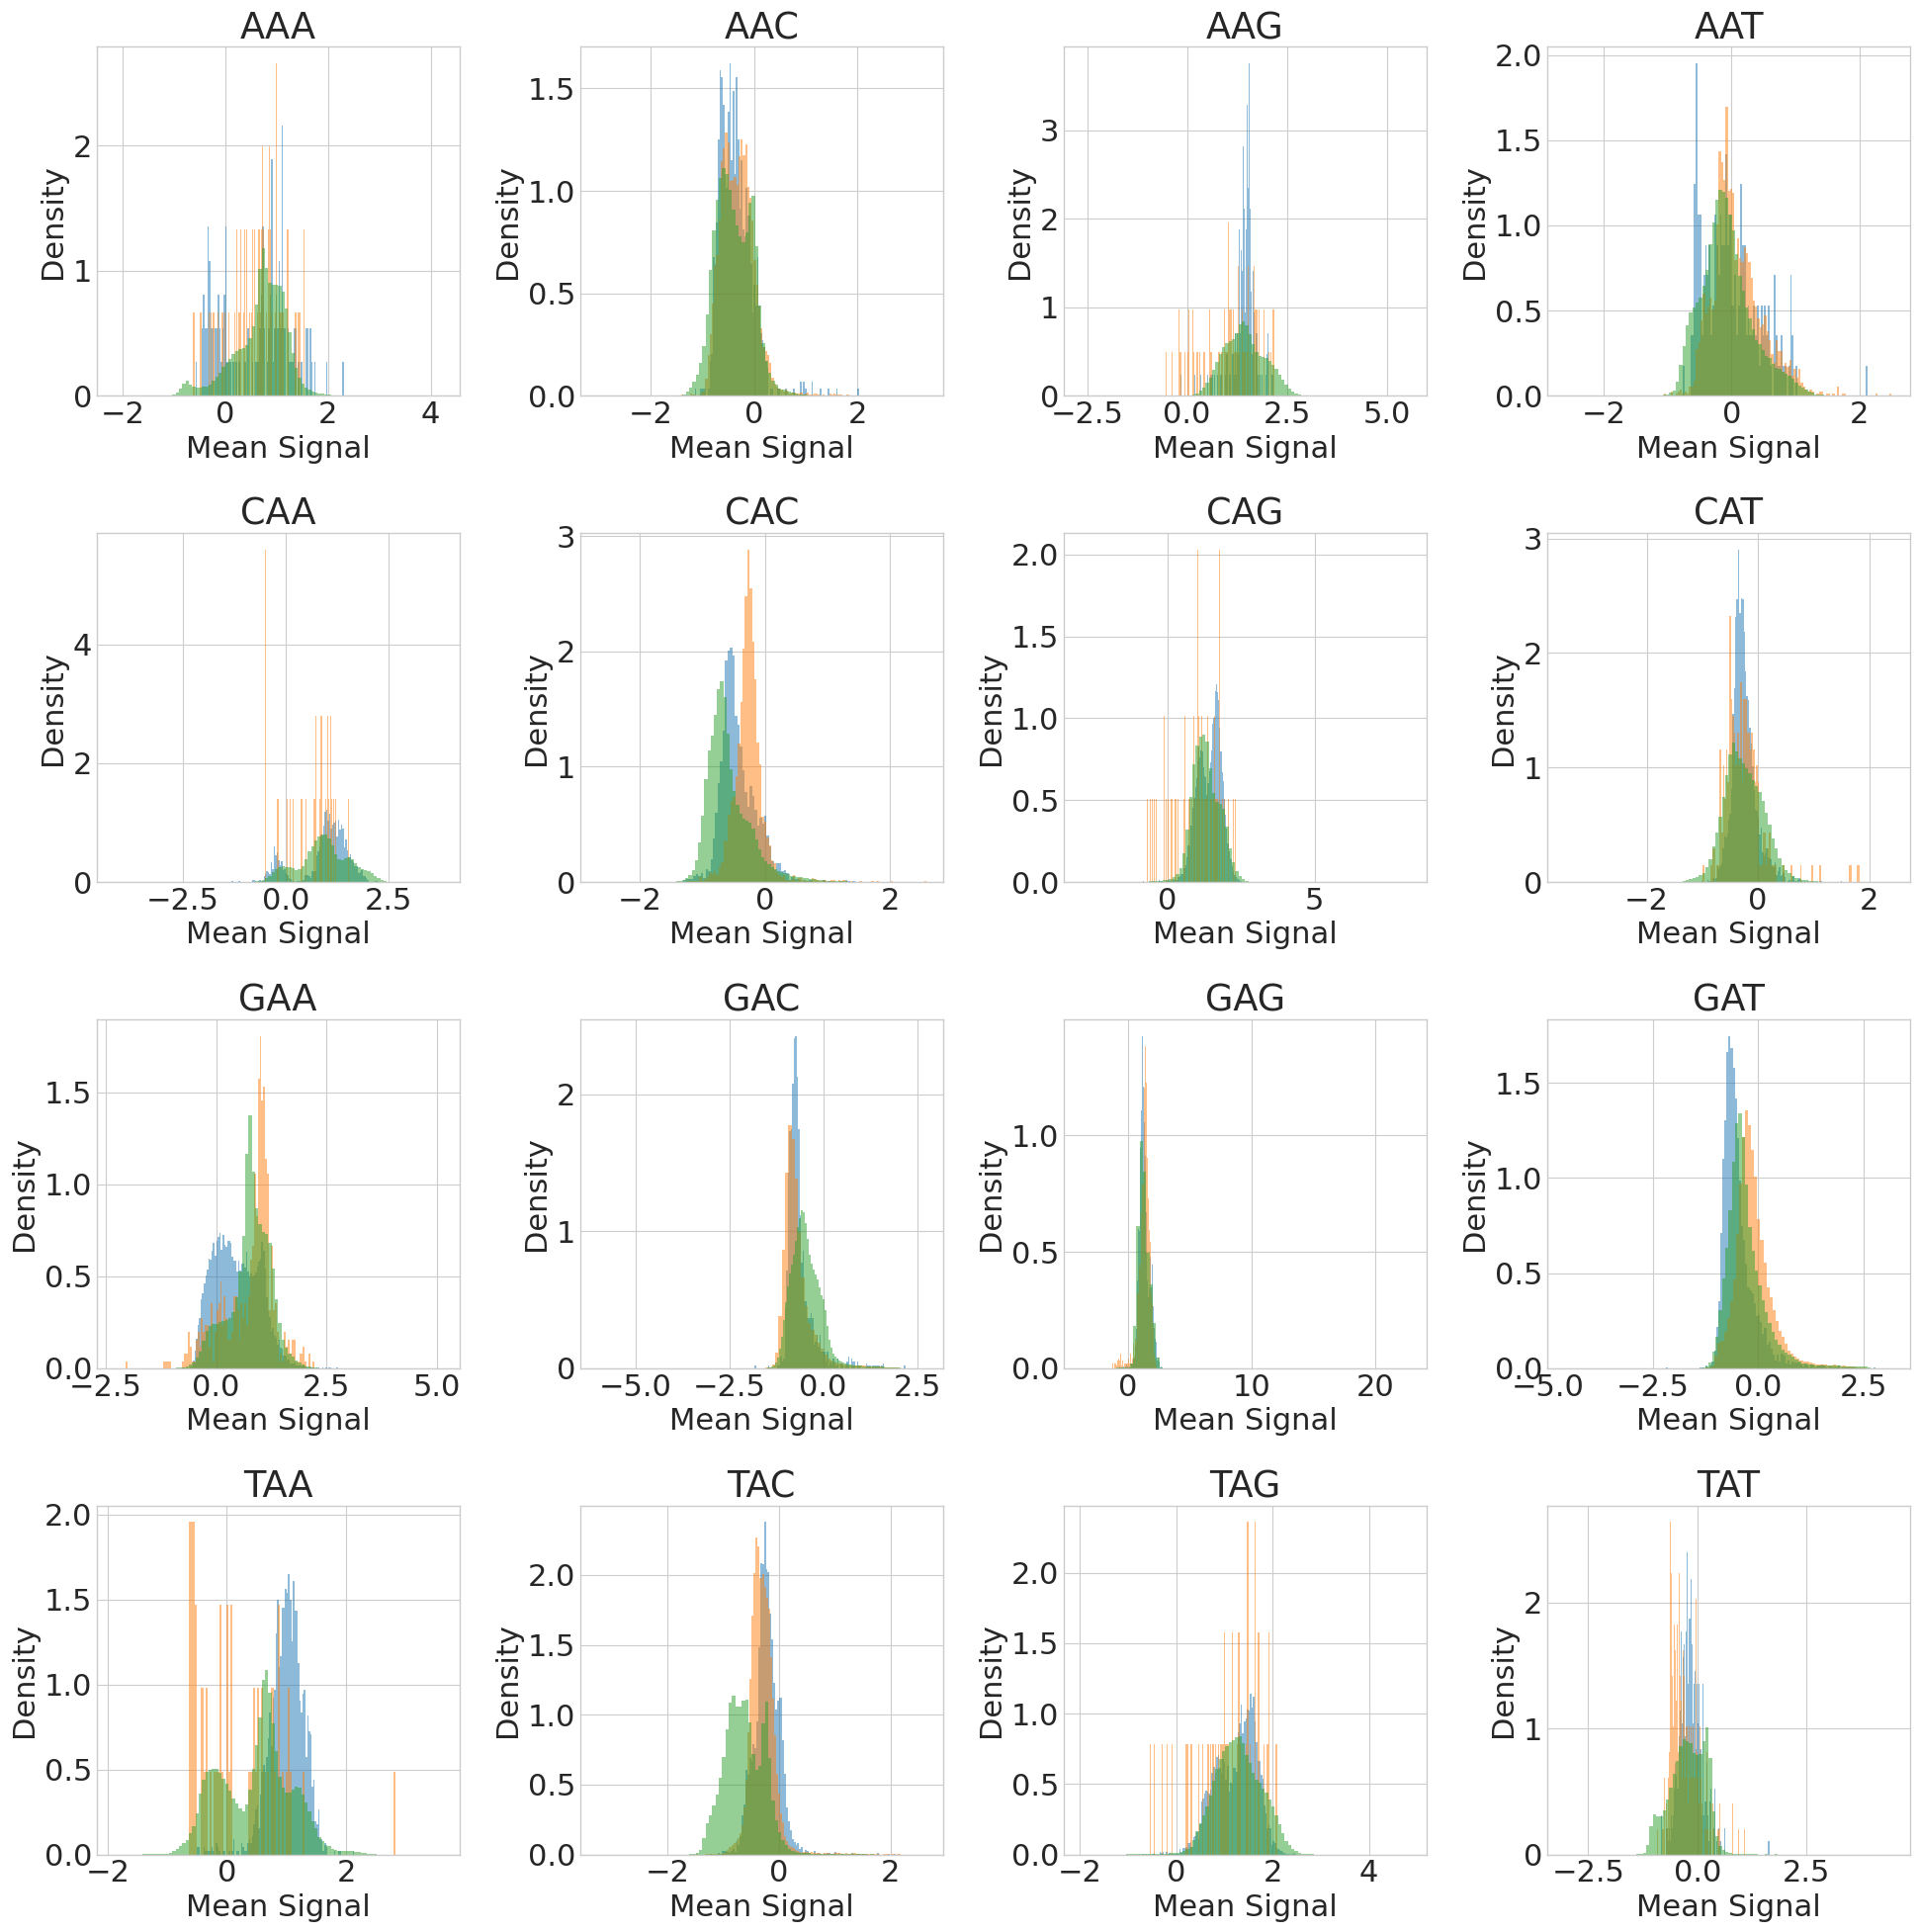

In [75]:
## Get BQ distribution 

gt_df = selected_df[(selected_df["label"]==1)].copy()
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_ids = fn_df["index"].values
tp_ids = tp_df["index"].values

fn_bool_idx = np.isin(pos_data["label_id"], fn_ids)
tp_bool_idx = np.isin(pos_data["label_id"], tp_ids)

fn_data = {key: pos_data[key][fn_bool_idx] for key in pos_data.keys()}
tp_data = {key: pos_data[key][tp_bool_idx] for key in pos_data.keys()}


def get_signal_data(data_dict):
    segment_len_arr = np.cumsum(data_dict["segment_len_arr"], axis = 1) * 6
    segment_slices = np.array([np.mean(data_dict["signal_token"][i,segment_len_arr[i,7]:segment_len_arr[i,8]])  for i in range(len(data_dict["signal_token"]))])
    return segment_slices

fn_signal = get_signal_data(fn_data)
tp_signal = get_signal_data(tp_data)
tn_signal = get_signal_data(tss_data)



## Breakdown by trimer
## Get BQ distribution 
fn_data["kmer_token"] = fn_data["kmer_token"].astype(np.int32)
tp_data["kmer_token"] = tp_data["kmer_token"].astype(np.int32)
tss_data["kmer_token"] = tss_data["kmer_token"].astype(np.int32)

fn_trimer_arr = fn_data["kmer_token"][:,9]*1000 + fn_data["kmer_token"][:,11]
tp_trimer_arr = tp_data["kmer_token"][:,9]*1000 + tp_data["kmer_token"][:,11]
tn_trimer_arr = tss_data["kmer_token"][:,9]*1000 + tss_data["kmer_token"][:,11]

print(fn_trimer_arr)
print(tp_trimer_arr)
print(tn_trimer_arr)

nuc_dict = {ord(x):x for x in "ACGT"}

fn_signal_dict = {}
tp_signal_dict = {}
tn_signal_dict = {}

for front in nuc_dict:
    for back in nuc_dict:
        seq = f"{nuc_dict[front]}A{nuc_dict[back]}"
        trimer = front * 1000 + back
        fn_signal_dict[seq] = fn_signal[(fn_trimer_arr == trimer)]
        tp_signal_dict[seq] = tp_signal[(tp_trimer_arr == trimer)]
        tn_signal_dict[seq] = tn_signal[(tn_trimer_arr == trimer)]

print(fn_signal_dict)

## Plot Histogram
fig, axes = plt.subplots(4, 4, figsize=(20,20))
for i, front in enumerate(nuc_dict):
    for j, back in enumerate(nuc_dict):
        seq = f"{nuc_dict[front]}A{nuc_dict[back]}"
        ax = axes[i,j]
        ax.hist(fn_signal_dict[seq], bins=100, alpha=0.5, label=f"False Negative (n={fn_signal_dict[seq].shape[0]:,})", density=True)
        ax.hist(tp_signal_dict[seq], bins=100, alpha=0.5, label=f"True Positive (n={tp_signal_dict[seq].shape[0]:,})", density=True)
        ax.hist(tn_signal_dict[seq], bins=100, alpha=0.5, label=f"True Negative (TSS) (n={tn_signal_dict[seq].shape[0]:,})", density=True)
        ax.set_xlabel("Mean Signal")
        ax.set_ylabel("Density")
        ax.set_title(f"{seq}")
fig.tight_layout()
plt.show()

In [76]:

pos_data["motif"] = np.array(["".join([chr(y) for y in x]) for x in pos_data["kmer_token"]])
pos_data["5mer"] = np.array([x[8:13] for x in pos_data["motif"]])

In [77]:
pd.Series(pos_data["5mer"]).value_counts()

AGATG    997401
GGATG    617796
TGATG    611488
GGATT    505744
AGATT    484735
          ...  
ACATA       135
TAACA       134
CAAAA        81
TAACC        69
TAAAA        43
Name: count, Length: 256, dtype: int64

In [78]:
pd.Series(tss_data["5mer"]).value_counts()

GCAGC    353875
GGAGC    281112
GGAGG    272135
GAAGA    202159
GCAGG    177874
          ...  
ATAAT       532
TCATA       454
TTATA       447
TAATA       144
ATATA        55
Name: count, Length: 256, dtype: int64

In [79]:

gt_df = selected_df[(selected_df["label"]==1)].copy()
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_ids = fn_df["index"].values
tp_ids = tp_df["index"].values

fn_bool_idx = np.isin(pos_data["label_id"], fn_ids)
tp_bool_idx = np.isin(pos_data["label_id"], tp_ids)

fn_data = {key: pos_data[key][fn_bool_idx] for key in pos_data.keys()}
tp_data = {key: pos_data[key][tp_bool_idx] for key in pos_data.keys()}


def get_signal_data(data_dict):
    segment_len_arr = np.cumsum(data_dict["segment_len_arr"], axis = 1) * 6
    segment_slices = np.array([np.mean(data_dict["signal_token"][i,segment_len_arr[i,7]:segment_len_arr[i,8]])  for i in range(len(data_dict["signal_token"]))])
    return segment_slices

fn_signal = get_signal_data(fn_data)
tp_signal = get_signal_data(tp_data)
tn_signal = get_signal_data(tss_data)


motifs = np.unique(tss_data["5mer"])


fn_signal_dict = {}
tp_signal_dict = {}
tn_signal_dict = {}


{'TAT': array([ 0.13480784, -0.28337726,  0.07156309, -0.15834646, -0.18288724,
       -0.15130155,  0.00163612, -0.68583506, -0.17359214,  0.25601292,
        0.48582697,  0.16434453, -0.12927006, -0.07620548], dtype=float32)}


In [81]:

for motif in motifs:
    fn_signal_dict[motif] = fn_signal[fn_data["5mer"] == motif]
    tp_signal_dict[motif] = tp_signal[tp_data["5mer"] == motif]
    tn_signal_dict[motif] = tn_signal[tss_data["5mer"] == motif]

print(fn_signal_dict)

{'TAT': array([ 0.13480784, -0.28337726,  0.07156309, -0.15834646, -0.18288724,
       -0.15130155,  0.00163612, -0.68583506, -0.17359214,  0.25601292,
        0.48582697,  0.16434453, -0.12927006, -0.07620548], dtype=float32), 'AAAAA': array([1.2290772], dtype=float32), 'AAAAC': array([], dtype=float32), 'AAAAG': array([1.2136364], dtype=float32), 'AAAAT': array([ 1.1070420e+00,  2.3063910e+00,  1.4338213e+00, -1.2549381e-02,
       -3.7490082e-01, -1.1461210e-01,  4.4142267e-01, -2.0344050e-01,
       -2.4835269e-09, -2.5296849e-01, -3.8861585e-01,  6.1919874e-01,
        4.2968282e-01,  1.9647453e+00,  8.6791962e-01,  7.3854858e-01],
      dtype=float32), 'AAACA': array([], dtype=float32), 'AAACC': array([], dtype=float32), 'AAACG': array([-0.28376588], dtype=float32), 'AAACT': array([-0.07615452,  0.04651029, -0.14663276, -0.09518238,  0.10427118,
        1.1410688 , -0.19729096, -0.07855564], dtype=float32), 'AAAGA': array([1.8945705], dtype=float32), 'AAAGC': array([1.3970999, 0.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:03<00:00, 71.18it/s]


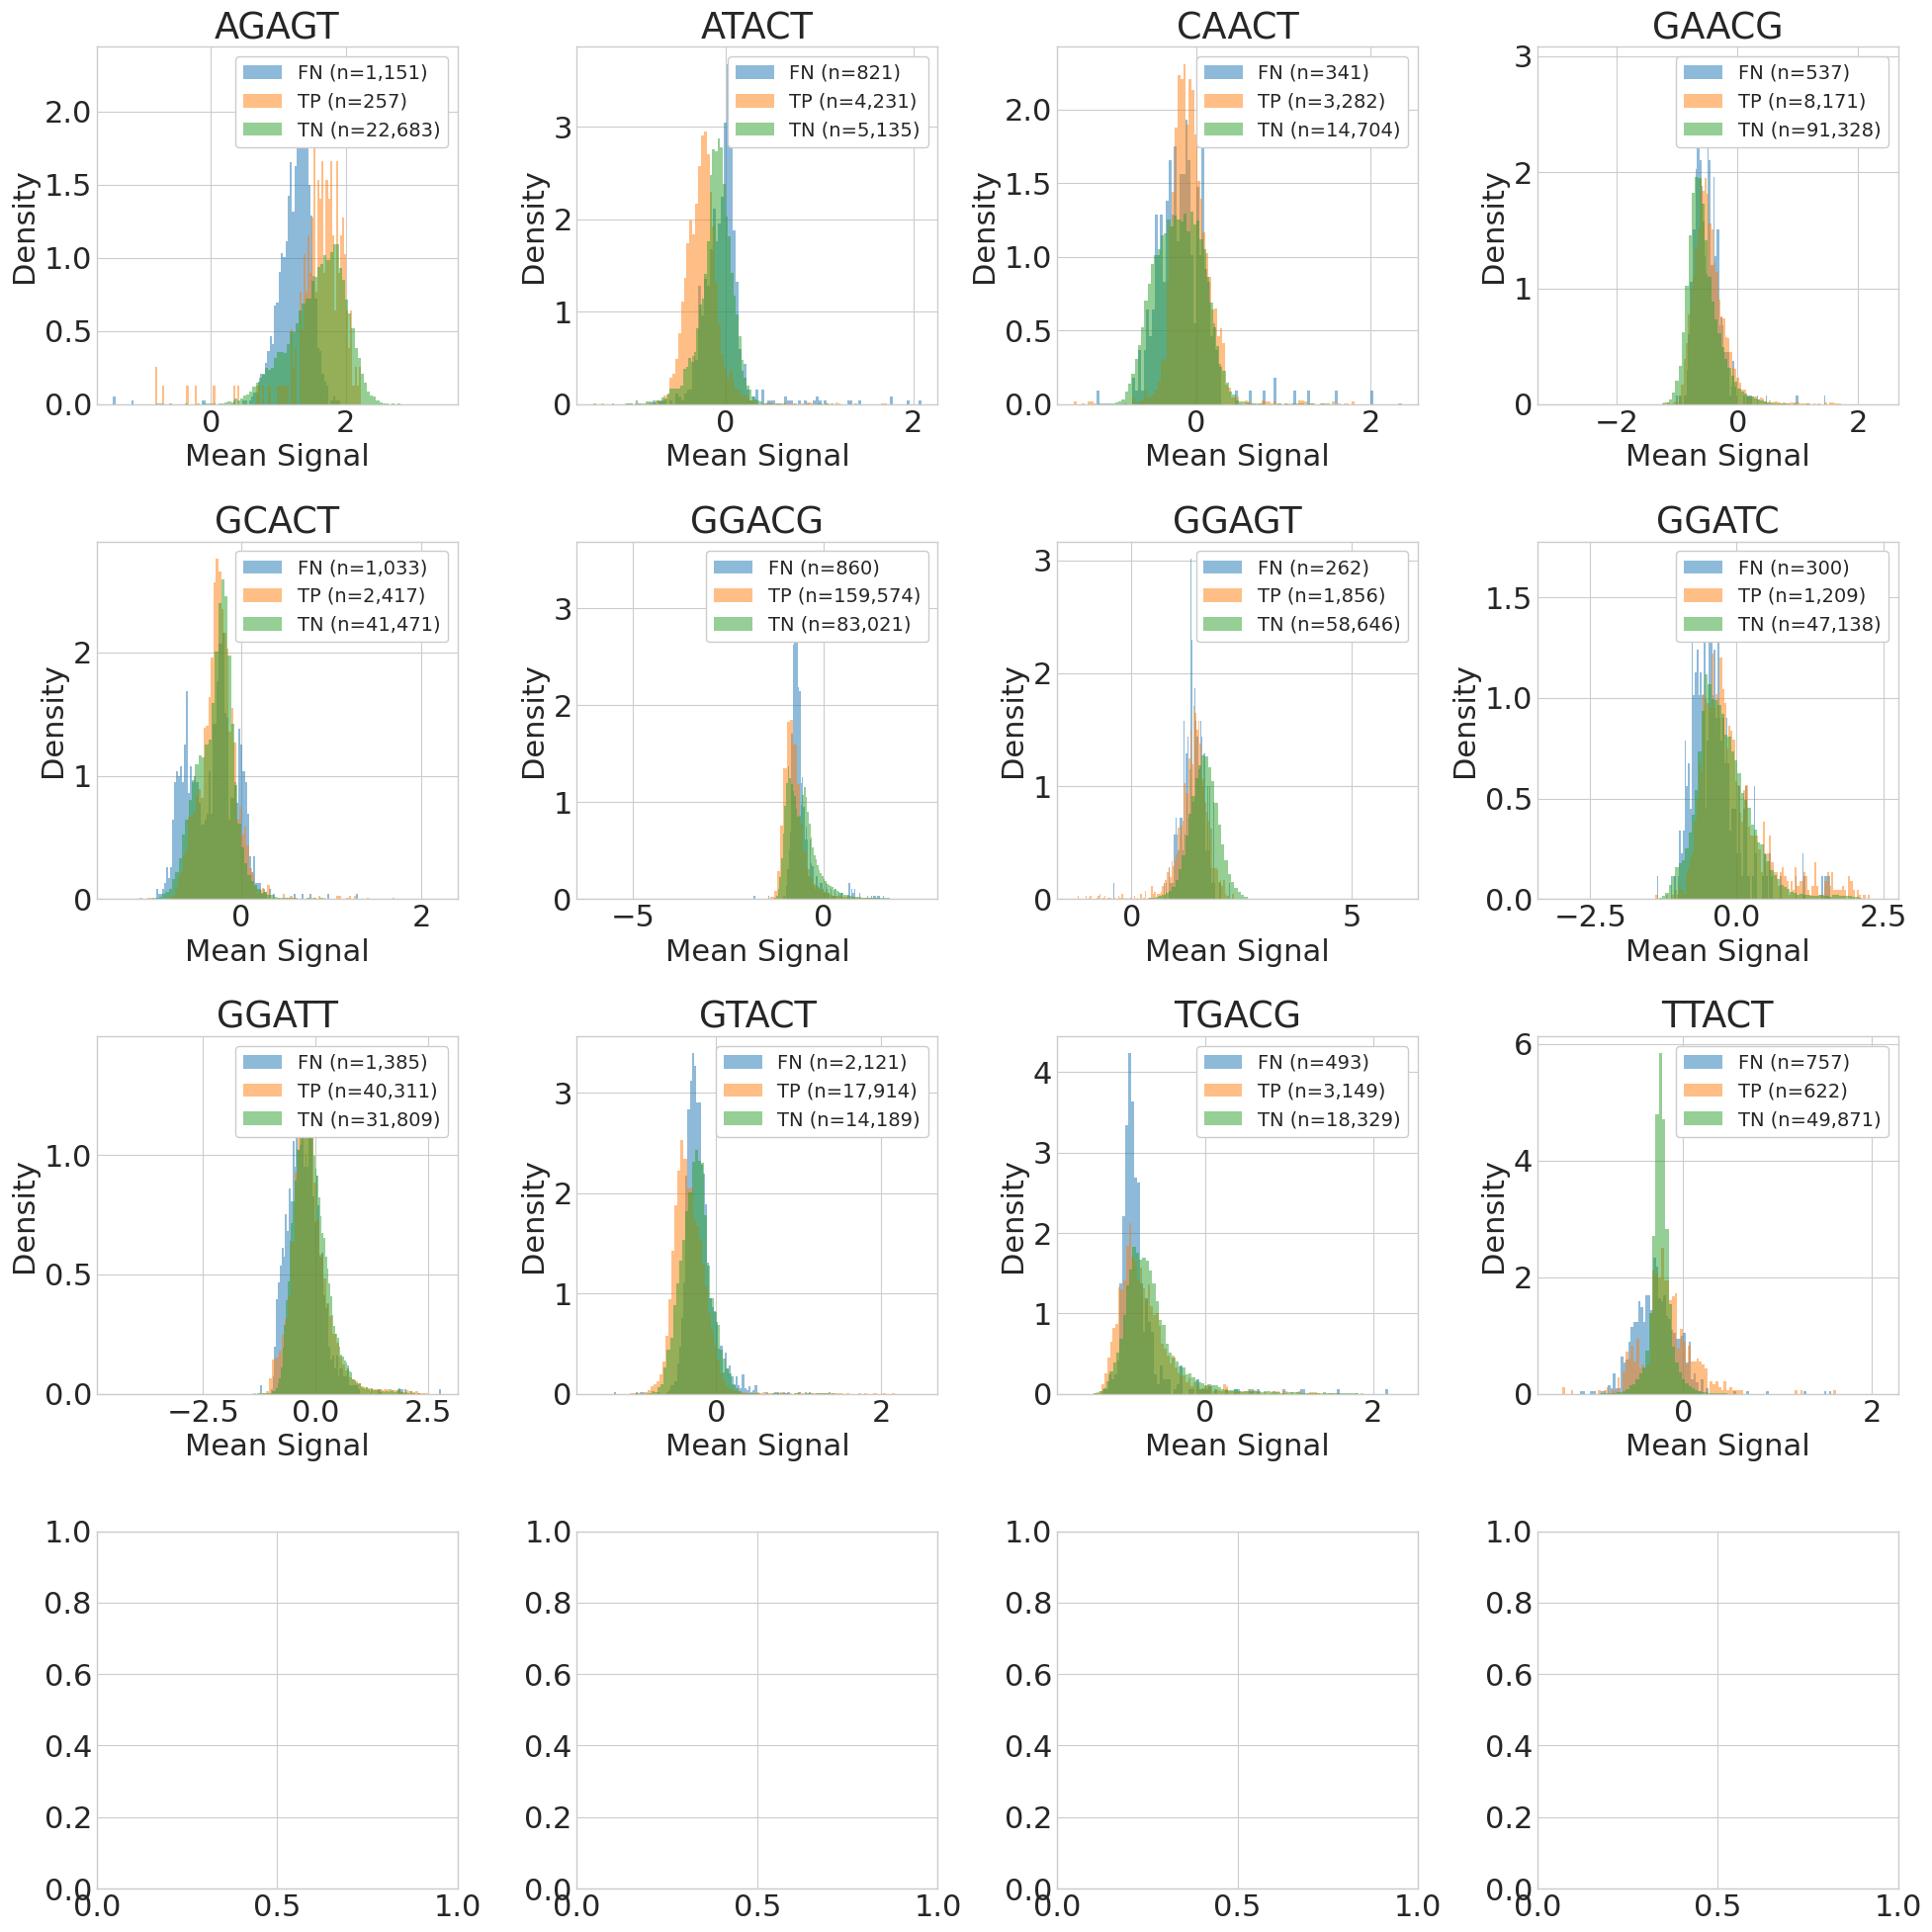

In [86]:
## Plot Histogram
fig, axes = plt.subplots(4, 4, figsize=(20,20))
count = 0
for motif in tqdm.tqdm(motifs): 
    ax = axes[count//4,count%4]
    
    if min(fn_signal_dict[motif].shape[0], tp_signal_dict[motif].shape[0], tn_signal_dict[motif].shape[0]) < 200:
        continue

    ax.hist(fn_signal_dict[motif], bins=100, alpha=0.5, label=f"FN (n={fn_signal_dict[motif].shape[0]:,})", density=True)
    ax.hist(tp_signal_dict[motif], bins=100, alpha=0.5, label=f"TP (n={tp_signal_dict[motif].shape[0]:,})", density=True)
    ax.hist(tn_signal_dict[motif], bins=100, alpha=0.5, label=f"TN (n={tn_signal_dict[motif].shape[0]:,})", density=True)
    ax.set_xlabel("Mean Signal")
    ax.set_ylabel("Density")
    ax.set_title(f"{motif}")
    ax.legend(loc="upper right", fontsize=14)
    count +=1
fig.tight_layout()
plt.show()

In [50]:

geneid_table = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/res/ref/GRCh38_latest_genomic.convert_table.pkl")
geneid_table.rename({"transcript_id":"refseq"}, axis=1, inplace=True)
geneid_table = geneid_table[geneid_table["refseq"].str.startswith("N")]
print(geneid_table)

            gene_id        refseq
6           DDX11L1     NR_046018
11           WASH7P     NR_024540
24        MIR6859-1     NR_106918
36        MIR1302-2     NR_036051
41          FAM138A     NR_026818
...             ...           ...
4656209     C4B_2_1  NM_001242823
4657766  HLA-DRB1_5  NM_001359194
4667458      LILRB5  NM_001412269
4671524    LILRA6_4  NM_001360167
4682896    KIR2DL5B  NM_001018081

[87410 rows x 2 columns]


In [48]:
from Bio import SeqIO
fasta = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
seq_dict = SeqIO.to_dict(SeqIO.parse(fasta, "fasta"))
seq_dict = {key.split(".")[0]: str(value.seq) for key, value in seq_dict.items()}

In [ ]:
gt_df["refseq"] = gt_df["label_id"].str.split(":").str[0]
gt_df = gt_df.merge(geneid_table, on="refseq", how="inner")

In [60]:
gt_df["pos"] = gt_df["label_id"].str.split(":").str[1].astype(np.int32)
gt_df["tlen"] = gt_df.apply(lambda x: len(seq_dict[x["refseq"]]), axis=1)
gt_df["seq"] = gt_df.apply(lambda x: seq_dict[x["refseq"]][max(0,x["pos"]-50):x["pos"]+50], axis=1)
print(gt_df)

            label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0     NM_000021:1942  88.616447     -0.027510     -279.817352         83   
1        NM_000077:6  20.494205     -0.008357       -1.719897          1   
2      NM_000098:943  23.932020     -0.006384      -47.663834         15   
3       NM_000113:24   3.333026      0.000000        0.000000          0   
4       NM_000126:26  12.546247     -0.003951       -2.043051          1   
...              ...        ...           ...             ...        ...   
2134  NR_163909:2006  17.469582     -0.017221      -36.163651         13   
2135   NR_163922:461  46.646519     -0.032779      -79.223328         26   
2136   NR_163924:596  32.716995     -0.018416      -62.043800         20   
2137  NR_182661:1592  13.311136     -0.005288      -33.037907         10   
2138  NR_182661:1637  31.849531     -0.037579      -66.474663         25   

      logsum_p_neg  logsum_1_p_neg  count_neg  logsum_p_all  logsum_1_p_all  \
0      -

In [61]:
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

In [62]:
fn_df[["refseq", "gene_id", "pos", "tlen", "seq"]]

,refseq,gene_id,pos,tlen,seq
1,NM_000077,CDKN2A,6,978,GAGAGCAGGCAGCGGGCGGCGGGGAGCAGCATGGAGCCGGCGGCGG...
3,NM_000113,TOR1A,24,2080,GCACCGGTTCGCGGTCGGCGCGAGAACAAGCAGGGTGGCGCGGGTC...
4,NM_000126,ETFA,26,2289,ATTAGGTGACTGGCTGAGGCGGCGCCAGTTGGCCGGGCACGGGGCT...
10,NM_000194,HPRT1,27,1395,AGCTTCAGGCGGCTGCGACGAGCCCTCAGGCGAACCTCTCGGCTTT...
20,NM_000382,ALDH3A2,3162,3703,AGCAAGTCAGAAGTTACTCTCATCAGTCGTTCATGGTCACAACCTG...
...,...,...,...,...,...
2114,NR_037672,SERF2,378,2477,AAGGGGCGGGACCTGCAACGTCCGACAGAACGAGGGGACGTAACGG...
2115,NR_037717,RNASEK-C17orf49,1055,1909,TATCCGCTGCGGGGAGGGCGGGACTTCCTGCGCGGGGGCCCGAGCC...
2116,NR_037853,ATP6V1G2-DDX39B,617,2305,AGAAGGCGGGAGGCTGGAGTAGAGGGAAGCCTGCAACCGGAAGTGA...
2129,NR_155756,TBCB,518,1943,CGCGGATTGGTCAGGCACGGAGCAGGAGGCGGGGCTGATAGCCCAG...


In [64]:
gt_df["rel_pos"] = gt_df["pos"] / gt_df["tlen"]

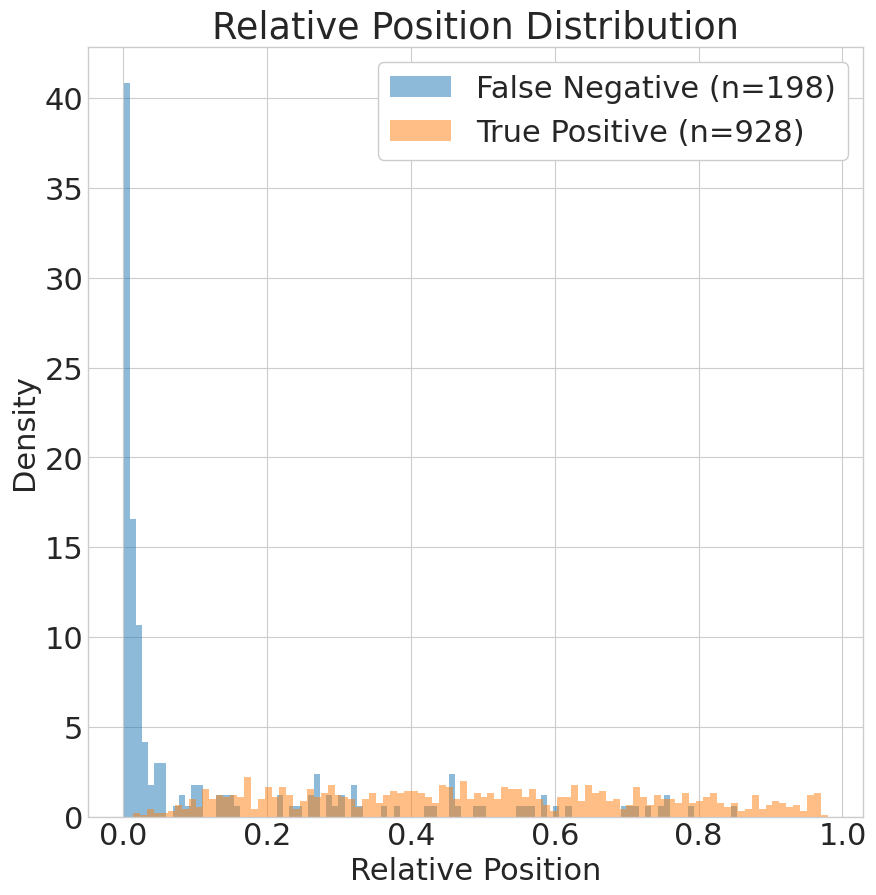

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(10,10))
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_df.hist("rel_pos", bins=100, ax=ax, alpha=0.5, label=f"False Negative (n={len(fn_df)})", density=True)
tp_df.hist("rel_pos", bins=100, ax=ax, alpha=0.5, label=f"True Positive (n={len(tp_df)})", density=True)
ax.set_xlabel("Relative Position")
ax.set_ylabel("Density")
ax.set_title("Relative Position Distribution")
ax.legend(loc="upper right")
plt.show()

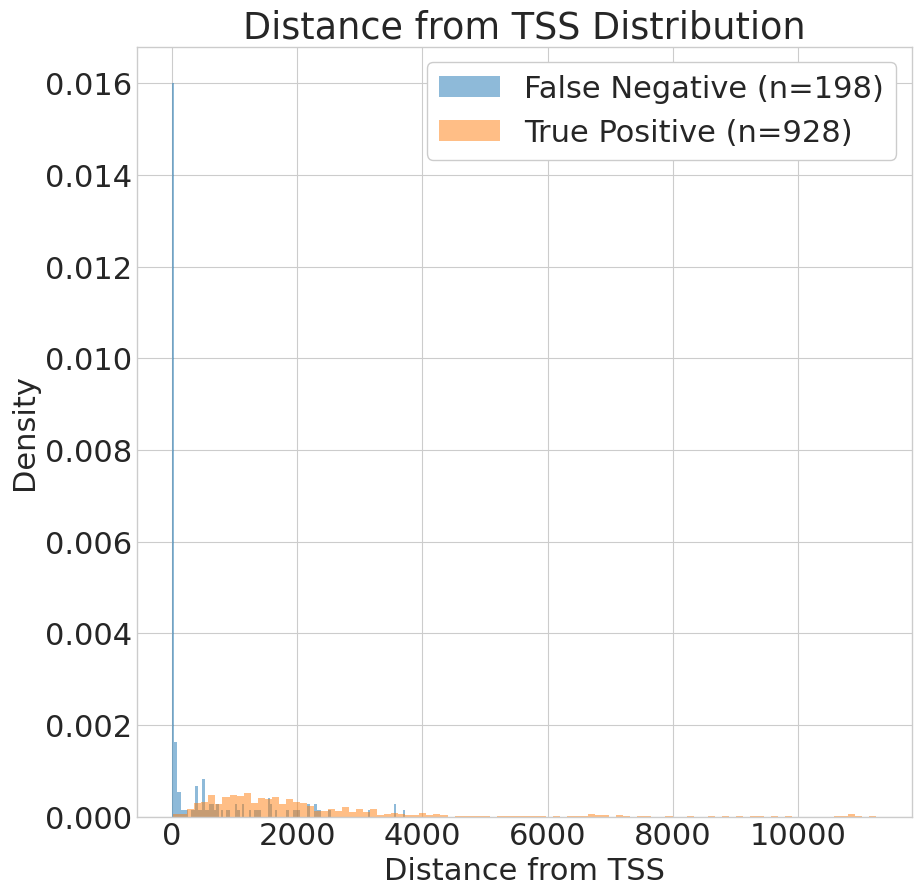

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(10,10))
fn_df = gt_df[gt_df["pm6a_pos_dom_v2"] <= 0.1].copy()
tp_df = gt_df[gt_df["pm6a_pos_dom_v2"] > 1.0].copy()

fn_df.hist("pos", bins=100, ax=ax, alpha=0.5, label=f"False Negative (n={len(fn_df)})", density=True)
tp_df.hist("pos", bins=100, ax=ax, alpha=0.5, label=f"True Positive (n={len(tp_df)})", density=True)
ax.set_xlabel("Distance from TSS")
ax.set_ylabel("Density")
ax.set_title("Distance from TSS Distribution")
ax.legend(loc="upper right")
plt.show()

In [70]:
## TODO: View FN sites on IGV - There might be something to do with the isoforms.

In [77]:
fasta_keys = list(SeqIO.to_dict(SeqIO.parse(fasta, "fasta")).keys())

In [79]:
refseq_ver_dict = {x.split(".")[0]: x for x in fasta_keys}


In [81]:
## get ids of fn sites
fn_ids = fn_df["label_id"].values
fn_ids = [f"{refseq_ver_dict[x.split(':')[0]]}:{x.split(':')[1]}" for x in fn_ids]
fn_ids

['NM_000077.5:6',
 'NM_000113.3:24',
 'NM_000126.4:26',
 'NM_000194.3:27',
 'NM_000382.3:3162',
 'NM_000942.5:3',
 'NM_001002800.3:3564',
 'NM_001003810.2:1318',
 'NM_001003962.3:23',
 'NM_001004333.5:10',
 'NM_001012.2:21',
 'NM_001014436.3:4',
 'NM_001018108.4:34',
 'NM_001032363.4:42',
 'NM_001034996.3:505',
 'NM_001037283.2:42',
 'NM_001039673.3:12',
 'NM_001040431.3:14',
 'NM_001042465.3:2',
 'NM_001042466.3:2',
 'NM_001071.4:28',
 'NM_001078166.2:2513',
 'NM_001098210.2:1561',
 'NM_001100626.2:60',
 'NM_001135998.3:10',
 'NM_001143985.1:424',
 'NM_001170795.4:320',
 'NM_001194947.2:1549',
 'NM_001199877.2:920',
 'NM_001204082.2:42',
 'NM_001270401.2:2195',
 'NM_001278556.2:12',
 'NM_001278556.2:4',
 'NM_001278640.2:22',
 'NM_001278640.2:25',
 'NM_001281.3:17',
 'NM_001281.3:20',
 'NM_001282.3:13',
 'NM_001291157.2:1645',
 'NM_001321967.2:33',
 'NM_001330221.2:379',
 'NM_001351779.2:2368',
 'NM_001352496.2:373',
 'NM_001352496.2:401',
 'NM_001360551.3:2022',
 'NM_001398.3:2',
 'NM

In [82]:
print(gt_df)

            label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0     NM_000021:1942  88.616447     -0.027510     -279.817352         83   
1        NM_000077:6  20.494205     -0.008357       -1.719897          1   
2      NM_000098:943  23.932020     -0.006384      -47.663834         15   
3       NM_000113:24   3.333026      0.000000        0.000000          0   
4       NM_000126:26  12.546247     -0.003951       -2.043051          1   
...              ...        ...           ...             ...        ...   
2134  NR_163909:2006  17.469582     -0.017221      -36.163651         13   
2135   NR_163922:461  46.646519     -0.032779      -79.223328         26   
2136   NR_163924:596  32.716995     -0.018416      -62.043800         20   
2137  NR_182661:1592  13.311136     -0.005288      -33.037907         10   
2138  NR_182661:1637  31.849531     -0.037579      -66.474663         25   

      logsum_p_neg  logsum_1_p_neg  count_neg  logsum_p_all  logsum_1_p_all  \
0      -

In [88]:
gt_df[gt_df["label_id"].str.startswith("NM_001195")]

,label_id,p_sum,logsum_p_pos,logsum_1_p_pos,count_pos,logsum_p_neg,logsum_1_p_neg,count_neg,logsum_p_all,logsum_1_p_all,...,drach,pred_dorado,dorado_count,pm6a_pos_dom_v2,refseq,gene_id,seq,pos,tlen,rel_pos
280,NM_001195328:547,61.123180,-0.043794,-148.152161,46,-688.616821,-0.376276,209,-695.328735,-163.769958,...,False,0.1822,269,0.913161,NM_001195328,RAB9A,AATTCATATATTATGCAGATGTGAAAGAGCCTGAGAGCTTTCCTTT...,547,1945,0.281234
281,NM_001195518:1865,84.461731,-0.039520,-274.453278,77,-841.457642,-0.262181,256,-846.043396,-281.511017,...,False,0.2153,339,1.341737,NM_001195518,MICU1,CACCTGCCAACCCTGGGAAGCATCCAGTTCTCAAATCGTTTTTGCT...,1865,2357,0.791260
282,NM_001195605:2426,86.624771,-0.082836,-198.818359,69,-43.081367,-0.060299,16,-48.755451,-220.114182,...,False,0.8396,106,2.005690,NM_001195605,ZNF865,GGAGGTGGGGGCGGCCGTGGCGGCACTGGCAGGGGTGTCTGGGGGT...,2426,3763,0.644698
283,NM_001195753:1150,54.368149,-0.003676,-169.783066,44,-154.186874,-0.318389,66,-161.787994,-177.537384,...,False,0.3934,122,1.958477,NM_001195753,THAP3,CAAGCTTATCCTCCCATGGTAACAGAAGTCCAGGCTGAGGCTGATT...,1150,1361,0.844967


In [89]:
fn_df["pos"].describe()

count     198.000000
mean      389.025253
std       743.835112
min         2.000000
25%        11.000000
50%        29.500000
75%       418.250000
max      3727.000000
Name: pos, dtype: float64

In [95]:
## Get first occurence of each id in data
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["dorado_count"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])


selected_df["pos"] = selected_df["label_id"].str.split(":").str[1].astype(np.int32)
neg_df = selected_df[(selected_df["label"]==0)]
tn_df = neg_df[neg_df["pm6a_pos_dom_v2"] <= 0.1]
fp_df = neg_df[neg_df["pm6a_pos_dom_v2"] > 1.0]

fn_tss_df = fn_df[fn_df["pos"] < 50].copy()
tn_tss_df = tn_df[tn_df["pos"] < 50].copy()

126
10674
1
0


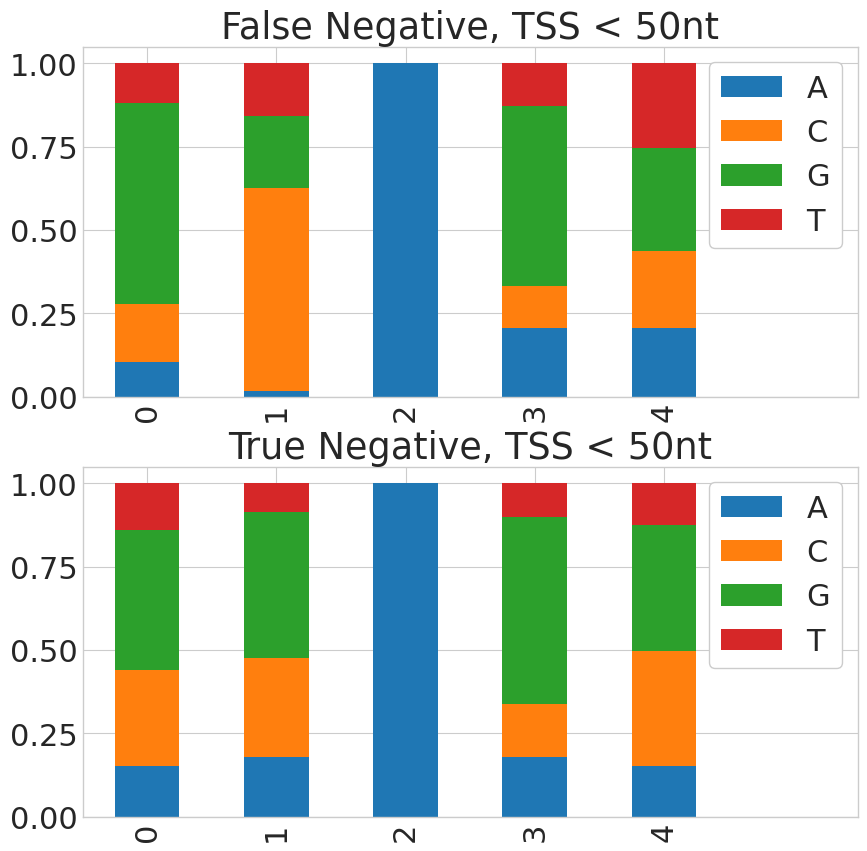

In [111]:
fn_nuc = get_nuc_frac_per_pos(np.array(fn_tss_df["5mer"].apply(list).to_list()).view(np.int32))
tn_nuc = get_nuc_frac_per_pos(np.array(tn_tss_df["5mer"].apply(list).to_list()).view(np.int32))

fn_nuc = pd.DataFrame(fn_nuc, columns=["A", "C", "G", "T"])
tn_nuc = pd.DataFrame(tn_nuc, columns=["A", "C", "G", "T"])

## Plot stacked bar
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fn_nuc.plot(kind="bar", stacked=True, ax=axes[0], legend="upper right")
tn_nuc.plot(kind="bar", stacked=True, ax=axes[1], legend="upper right")
axes[0].set_title("False Negative, TSS < 50nt")
axes[1].set_title("True Negative, TSS < 50nt")
axes[0].set_xlim(-0.5,5.5)
axes[1].set_xlim(-0.5,5.5)
plt.show()


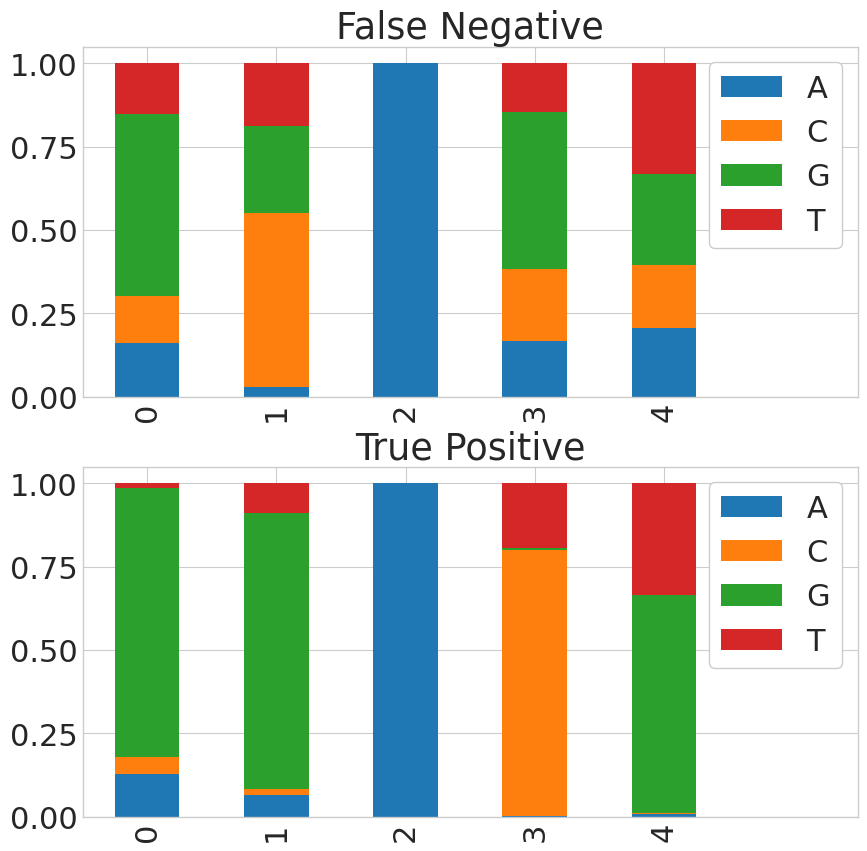

In [113]:
fn_nuc = get_nuc_frac_per_pos(np.array(fn_df["5mer"].apply(list).to_list()).view(np.int32))
tp_nuc = get_nuc_frac_per_pos(np.array(tp_df["5mer"].apply(list).to_list()).view(np.int32))

fn_nuc = pd.DataFrame(fn_nuc, columns=["A", "C", "G", "T"])
tp_nuc = pd.DataFrame(tp_nuc, columns=["A", "C", "G", "T"])

## Plot stacked bar
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fn_nuc.plot(kind="bar", stacked=True, ax=axes[0], legend="upper right")
tp_nuc.plot(kind="bar", stacked=True, ax=axes[1], legend="upper right")
axes[0].set_title("False Negative")
axes[1].set_title("True Positive")
axes[0].set_xlim(-0.5,5.5)
axes[1].set_xlim(-0.5,5.5)
plt.show()


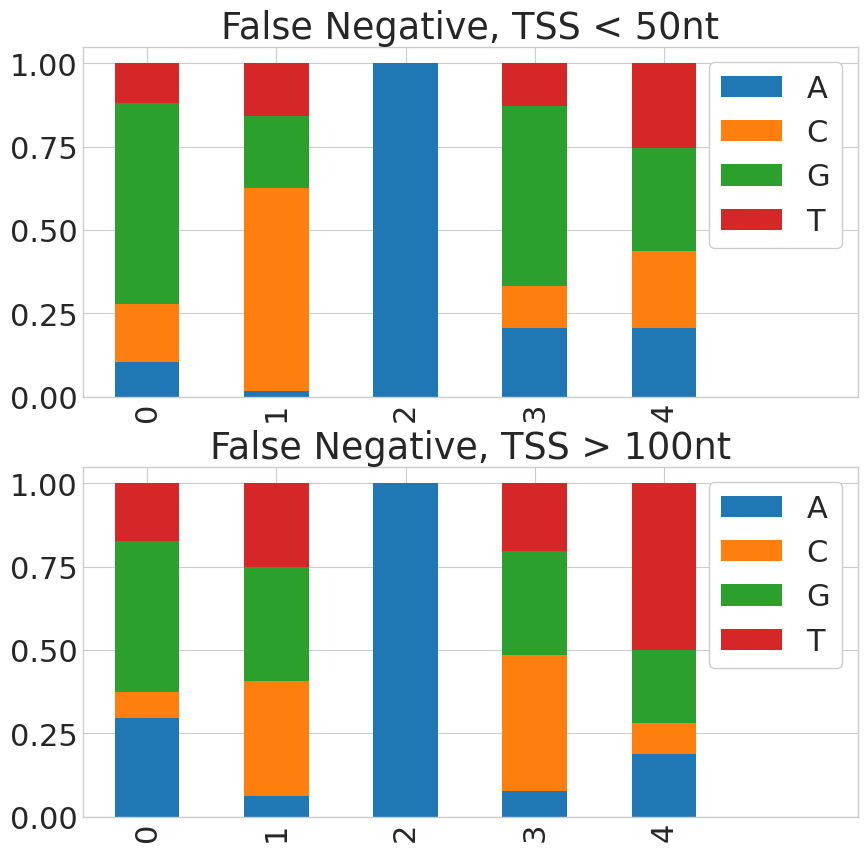

In [114]:
fn_tss1_df = fn_df[fn_df["pos"] < 50].copy()
fn_tss2_df = fn_df[fn_df["pos"] > 100].copy()

fn_tss1_df = get_nuc_frac_per_pos(np.array(fn_tss1_df["5mer"].apply(list).to_list()).view(np.int32))
fn_tss2_df = get_nuc_frac_per_pos(np.array(fn_tss2_df["5mer"].apply(list).to_list()).view(np.int32))

fn_tss1_df = pd.DataFrame(fn_tss1_df, columns=["A", "C", "G", "T"])
fn_tss2_df = pd.DataFrame(fn_tss2_df, columns=["A", "C", "G", "T"])

## Plot stacked bar
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fn_tss1_df.plot(kind="bar", stacked=True, ax=axes[0], legend="upper right")
fn_tss2_df.plot(kind="bar", stacked=True, ax=axes[1], legend="upper right")
axes[0].set_title("False Negative, TSS < 50nt")
axes[1].set_title("False Negative, TSS > 100nt")
axes[0].set_xlim(-0.5,5.5)
axes[1].set_xlim(-0.5,5.5)
plt.show()


In [115]:
fn_df

,label_id,p_sum,logsum_p_pos,logsum_1_p_pos,count_pos,logsum_p_neg,logsum_1_p_neg,count_neg,logsum_p_all,logsum_1_p_all,...,drach,pred_dorado,dorado_count,pm6a_pos_dom_v2,refseq,gene_id,seq,pos,tlen,rel_pos
1,NM_000077:6,20.494205,-0.008357,-1.719897,1,-1384.737061,-1.721116,503,-1410.044922,-15.969685,...,False,0.0700,586,0.006156,NM_000077,CDKN2A,GAGAGCAGGCAGCGGGCGGCGGGGAGCAGCATGGAGCCGGCGGCGGGGAGCAGCAT,6,978,0.006135
3,NM_000113:24,3.333026,0.000000,0.000000,0,-984.767883,-0.292922,296,-989.415100,-1.989055,...,False,0.0000,354,-0.000000,NM_000113,TOR1A,GCACCGGTTCGCGGTCGGCGCGAGAACAAGCAGGGTGGCGCGGGTCCGGGCATGAAGCTGGGCCGGGCCGTGCT,24,2080,0.011538
4,NM_000126:26,12.546247,-0.003951,-2.043051,1,-937.564270,-0.830799,319,-948.979309,-10.096399,...,False,0.0436,344,0.011623,NM_000126,ETFA,ATTAGGTGACTGGCTGAGGCGGCGCCAGTTGGCCGGGCACGGGGCTGCTGTAAGGCCGAGGTTGCGGCGGAAGCGG,26,2289,0.011359
10,NM_000194:27,5.974673,0.000000,0.000000,0,-368.602203,-0.757488,148,-374.052216,-3.554713,...,False,0.0064,156,-0.000000,NM_000194,HPRT1,AGCTTCAGGCGGCTGCGACGAGCCCTCAGGCGAACCTCTCGGCTTTCCCGCGCGGCGCCGCCTCTTGCTGCGCCTCC,27,1395,0.019355
20,NM_000382:3162,13.462358,-0.017976,-5.653060,3,-286.363190,-0.138303,93,-294.635803,-13.883297,...,False,0.1250,104,0.088724,NM_000382,ALDH3A2,AGCAAGTCAGAAGTTACTCTCATCAGTCGTTCATGGTCACAACCTGAGGTACTCTGCTGAGTGGGCAAGGCTGAAGAAGAGGCCTGTGGAATGCAGCATT,3162,3703,0.853902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2114,NR_037672:378,4.850079,0.000000,0.000000,0,-525.052124,-0.815662,198,-531.793884,-2.475751,...,False,0.0462,195,-0.000000,NR_037672,SERF2,AAGGGGCGGGACCTGCAACGTCCGACAGAACGAGGGGACGTAACGGAGGCAGGTTGGAGCCGCTGCCGTCGCCATGACCCGCGGTAACCAGCGTGAGCTC,378,2477,0.152604
2115,NR_037717:1055,22.541828,-0.006153,-4.684024,2,-125.523842,-0.790417,69,-149.003082,-20.925402,...,False,0.0446,112,0.071081,NR_037717,RNASEK-C17orf49,TATCCGCTGCGGGGAGGGCGGGACTTCCTGCGCGGGGGCCCGAGCCGCTCAGTCTCCCTGCTCTCCGTGGTCCCGGCTCGCGTGTAGCGGCGGCGGCGGC,1055,1909,0.552645
2116,NR_037853:617,6.251710,0.000000,0.000000,0,-277.258484,-0.277006,105,-285.209869,-4.145258,...,False,0.0180,111,-0.000000,NR_037853,ATP6V1G2-DDX39B,AGAAGGCGGGAGGCTGGAGTAGAGGGAAGCCTGCAACCGGAAGTGAAGGCAGATTTCCCTCCTTCGTCGCTGTTGCTGCCGCCATACGCGCTCTCCCTGT,617,2305,0.267679
2129,NR_155756:518,5.714204,0.000000,0.000000,0,-231.255142,-0.492335,98,-238.460754,-3.768551,...,False,0.0190,105,-0.000000,NR_155756,TBCB,CGCGGATTGGTCAGGCACGGAGCAGGAGGCGGGGCTGATAGCCCAGCAGCAGCAGCGGCGGCGGCGGCTGCGGAGCGGGTGTGAGGCGGCTGGACCGCGC,518,1943,0.266598


In [118]:
glori_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/glori_reformatted.tsv", sep="\t")
glori_df["label_id"] = glori_df["NMID"] + ":" + glori_df["transcript_coordinate"].astype(str)
glori_df

,Chr,Strand,Sites,m6A_level_rep1,m6A_level_rep2,chrstrand,NMID,transcript_coordinate,label_id
0,chr9,+,134440485,0.69333,0.77922,chr9+,NM_002957,5437,NM_002957:5437
1,chr9,+,134440485,0.69333,0.77922,chr9+,NM_001291920,6101,NM_001291920:6101
2,chr9,+,134440485,0.69333,0.77922,chr9+,NM_001291921,5914,NM_001291921:5914
3,chr9,-,137300014,0.78736,0.82895,chr9-,NM_001004354,2256,NM_001004354:2256
4,chr9,-,137300274,0.62796,0.66242,chr9-,NM_001004354,1996,NM_001004354:1996
...,...,...,...,...,...,...,...,...,...
495172,chr17,+,48051150,0.91228,0.89783,chr17+,NM_001330262,648,NM_001330262:648
495173,chr17,+,48051150,0.91228,0.89783,chr17+,NM_001330261,648,NM_001330261:648
495174,chr17,+,48051197,0.34035,0.36547,chr17+,NM_003204,695,NM_003204:695
495175,chr17,+,48051197,0.34035,0.36547,chr17+,NM_001330262,695,NM_001330262:695


In [127]:
from scipy import stats

In [128]:
from scipy import stats
contingency = [[13,1],[14909,8549]]

In [ ]:
fn_nuc = get_nuc_frac_per_pos(np.array(fn_df["5mer"].apply(list).to_list()).view(np.int32))
tp_nuc = get_nuc_frac_per_pos(np.array(tp_df["5mer"].apply(list).to_list()).view(np.int32))

fn_nuc = pd.DataFrame(fn_nuc, columns=["A", "C", "G", "T"])
tp_nuc = pd.DataFrame(tp_nuc, columns=["A", "C", "G", "T"])

## Plot stacked bar
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fn_nuc.plot(kind="bar", stacked=True, ax=axes[0], legend="upper right")
tp_nuc.plot(kind="bar", stacked=True, ax=axes[1], legend="upper right")
axes[0].set_title("False Negative")
axes[1].set_title("True Positive")
axes[0].set_xlim(-0.5,5.5)
axes[1].set_xlim(-0.5,5.5)
plt.show()


In [19]:
print(label_df_filtered)

             index        label_id  depth  label  dom_label   5mer  drach
0                0    NM_000084:34      7      0        0.0  GCAGA  False
1                1    NM_000084:36      7      0        0.0  AGAGA  False
2                2    NM_000084:38      7      0        0.0  AGAAT  False
3                3    NM_000084:39      7      0        0.0  GAATG  False
4                4    NM_000084:43      7      0        0.0  GCAGC  False
...            ...             ...    ...    ...        ...    ...    ...
30960221  30960221  NR_176252:1213     37      0        0.0  TTACT  False
30960222  30960222  NR_176252:1218     36      0        0.0  TTAAA  False
30960223  30960223  NR_176252:1219     36      0        0.0  TAAAA  False
30960224  30960224  NR_176252:1220     36      0        0.0  AAAAT  False
30960225  30960225  NR_176252:1221     36      0        0.0  AAATG  False

[18499997 rows x 7 columns]


In [21]:
print(label_df_filtered[label_df_filtered["dom_label"] >= 0.1])

             index           label_id  depth  label  dom_label   5mer  drach
420            420     NM_000084:1800      9      1   0.693506  GAACT   True
545            545     NM_000084:2290     14      1   0.254772  TGACT   True
2994          2994     NM_000319:1976     10      1   0.285758  TGACA   True
5415          5415  NM_001003891:2571     96      1   0.247348  GGACC   True
5427          5427  NM_001003891:2603     95      1   0.538194  GAACT   True
...            ...                ...    ...    ...        ...    ...    ...
30959546  30959546     NR_165407:1498      6      1   0.695436  TGACT   True
30959547  30959547     NR_165407:1503      6      1   0.856464  GGACT   True
30959669  30959669     NR_165407:1851      7      1   0.751588  GGACT   True
30960000  30960000      NR_176252:405     20      1   0.113463  GGACT   True
30960074  30960074      NR_176252:660     26      1   0.123914  GGACT   True

[89922 rows x 7 columns]


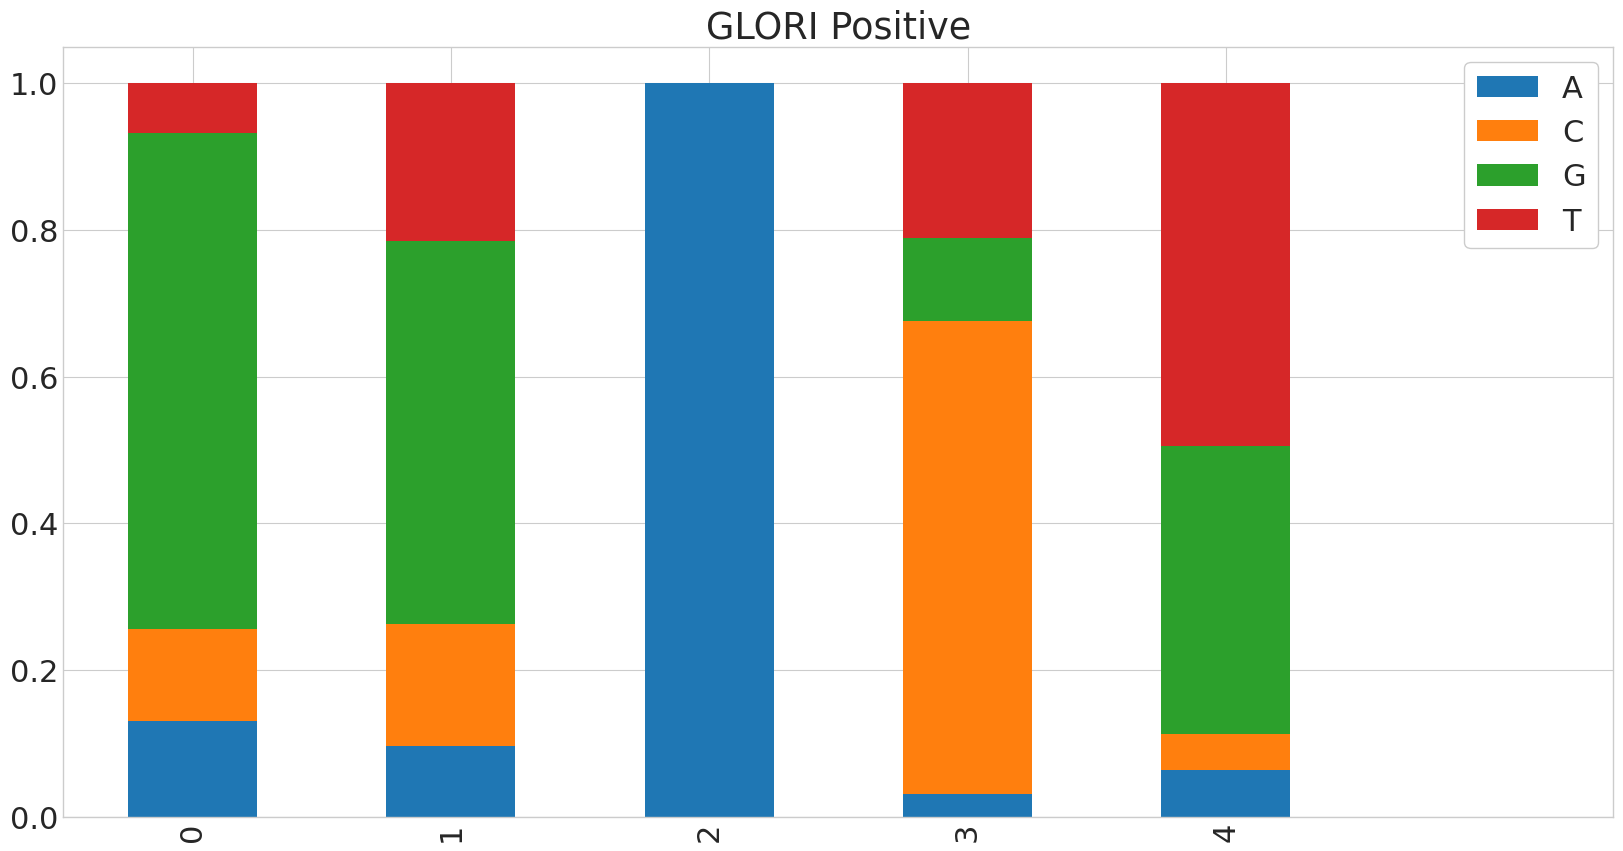

In [26]:
nuc = get_nuc_frac_per_pos(np.array(label_df_filtered[(label_df_filtered["dom_label"] >= 0.1) & (~label_df_filtered["drach"])]["5mer"].apply(list).to_list()).view(np.int32))

nuc = pd.DataFrame(nuc, columns=["A", "C", "G", "T"]) 

## Plot stacked bar
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
nuc.plot(kind="bar", stacked=True, ax=ax, legend="upper right")
ax.set_title("GLORI Positive")
ax.set_xlim(-0.5,5.5)
plt.show()


In [87]:
jungmin_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/m6A_Jungmin_110823.tsv", sep="\t")
jungmin_df

,chr,str,pos,DoM,SAC,GLORI,MICLIP2,M6ACE,validated,chrstrand,NMID,transcript_coordinate
0,chrX,+,47054489,0.288278,False,True,False,False,1,chrX+,NM_001077445,1355
1,chrX,+,47054489,0.288278,False,True,False,False,1,chrX+,NM_014735,1614
2,chrX,+,47058193,0.130435,False,True,False,False,1,chrX+,NM_001077445,1639
3,chrX,+,47058193,0.130435,False,True,False,False,1,chrX+,NM_014735,1898
4,chrX,+,47058259,0.000000,True,False,False,False,1,chrX+,NM_001077445,1705
...,...,...,...,...,...,...,...,...,...,...,...,...
2803625,chr3,-,48165668,0.000000,True,False,False,False,1,chr3-,NM_001789,1627
2803626,chr3,-,48165733,0.021908,False,True,False,False,1,chr3-,NM_201567,1442
2803627,chr3,-,48165733,0.021908,False,True,False,False,1,chr3-,NM_001789,1562
2803628,chr3,-,48167902,0.000000,True,False,False,False,1,chr3-,NM_201567,1321


In [88]:
glori_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/glori_reformatted.tsv", sep="\t")
glori_df

,Chr,Strand,Sites,m6A_level_rep1,m6A_level_rep2,chrstrand,NMID,transcript_coordinate
0,chr9,+,134440485,0.69333,0.77922,chr9+,NM_002957,5437
1,chr9,+,134440485,0.69333,0.77922,chr9+,NM_001291920,6101
2,chr9,+,134440485,0.69333,0.77922,chr9+,NM_001291921,5914
3,chr9,-,137300014,0.78736,0.82895,chr9-,NM_001004354,2256
4,chr9,-,137300274,0.62796,0.66242,chr9-,NM_001004354,1996
...,...,...,...,...,...,...,...,...
495172,chr17,+,48051150,0.91228,0.89783,chr17+,NM_001330262,648
495173,chr17,+,48051150,0.91228,0.89783,chr17+,NM_001330261,648
495174,chr17,+,48051197,0.34035,0.36547,chr17+,NM_003204,695
495175,chr17,+,48051197,0.34035,0.36547,chr17+,NM_001330262,695


In [89]:
jungmin_df.drop(columns=["GLORI", "DoM", "chr", "str", "pos", "validated", "chrstrand"], inplace=True)

In [91]:
jungmin_df["label_id"] = jungmin_df["NMID"] + ":" + jungmin_df["transcript_coordinate"].astype(str)
jungmin_df["validated"] = jungmin_df[["SAC", "MICLIP2", "M6ACE"]].astype(int).sum(axis=1)
jungmin_df = jungmin_df[jungmin_df["validated"] > 0]
jungmin_df

,SAC,MICLIP2,M6ACE,NMID,transcript_coordinate,label_id,validated
4,True,False,False,NM_001077445,1705,NM_001077445:1705,1
5,True,False,False,NM_014735,1964,NM_014735:1964,1
6,True,False,False,NM_001077445,1753,NM_001077445:1753,1
7,True,False,False,NM_014735,2012,NM_014735:2012,1
8,False,False,True,NM_001077445,1783,NM_001077445:1783,1
...,...,...,...,...,...,...,...
2803623,True,False,False,NM_001789,1644,NM_001789:1644,1
2803624,True,False,False,NM_201567,1507,NM_201567:1507,1
2803625,True,False,False,NM_001789,1627,NM_001789:1627,1
2803628,True,False,False,NM_201567,1321,NM_201567:1321,1


In [93]:
glori_df["label_id"] = glori_df["NMID"] + ":" + glori_df["transcript_coordinate"].astype(str)
glori_df["DoM"] = (glori_df["m6A_level_rep1"] + glori_df["m6A_level_rep2"]) / 2
glori_df.drop(columns=["NMID", "transcript_coordinate", "m6A_level_rep1", "m6A_level_rep2"], inplace=True)
glori_df

,Chr,Strand,Sites,chrstrand,label_id,DoM
0,chr9,+,134440485,chr9+,NM_002957:5437,0.736275
1,chr9,+,134440485,chr9+,NM_001291920:6101,0.736275
2,chr9,+,134440485,chr9+,NM_001291921:5914,0.736275
3,chr9,-,137300014,chr9-,NM_001004354:2256,0.808155
4,chr9,-,137300274,chr9-,NM_001004354:1996,0.645190
...,...,...,...,...,...,...
495172,chr17,+,48051150,chr17+,NM_001330262:648,0.905055
495173,chr17,+,48051150,chr17+,NM_001330261:648,0.905055
495174,chr17,+,48051197,chr17+,NM_003204:695,0.352910
495175,chr17,+,48051197,chr17+,NM_001330262:695,0.352910


In [94]:
glori_df.drop(columns=["Chr", "Strand", "Sites"], inplace=True)
jungmin_df = jungmin_df.merge(glori_df, on="label_id", how="outer")
jungmin_df

,SAC,MICLIP2,M6ACE,NMID,transcript_coordinate,label_id,validated,chrstrand,DoM
0,True,False,False,NM_001077445,1705.0,NM_001077445:1705,1.0,NaN,NaN
1,True,False,False,NM_014735,1964.0,NM_014735:1964,1.0,NaN,NaN
2,True,False,False,NM_001077445,1753.0,NM_001077445:1753,1.0,NaN,NaN
3,True,False,False,NM_014735,2012.0,NM_014735:2012,1.0,NaN,NaN
4,False,False,True,NM_001077445,1783.0,NM_001077445:1783,1.0,chrX+,0.417850
...,...,...,...,...,...,...,...,...,...
2352902,NaN,NaN,NaN,NaN,NaN,NM_001330262:358,NaN,chr17+,0.204905
2352903,NaN,NaN,NaN,NaN,NaN,NM_001330261:358,NaN,chr17+,0.204905
2352904,NaN,NaN,NaN,NaN,NaN,NM_003204:366,NaN,chr17+,0.170475
2352905,NaN,NaN,NaN,NaN,NaN,NM_001330262:366,NaN,chr17+,0.170475


In [97]:
jungmin_df.fillna(0, inplace=True)
jungmin_df["GLORI"] = jungmin_df["DoM"] > 0
jungmin_df["NMID"] = jungmin_df["label_id"].str.split(":").str[0]
jungmin_df["transcript_coordinate"] = jungmin_df["label_id"].str.split(":").str[1]
jungmin_df["validated"] = jungmin_df[["SAC", "MICLIP2", "M6ACE", "GLORI"]].astype(int).sum(axis=1)

In [98]:
jungmin_df

,SAC,MICLIP2,M6ACE,NMID,transcript_coordinate,label_id,validated,chrstrand,DoM,GLORI
0,True,False,False,NM_001077445,1705,NM_001077445:1705,1,0,0.000000,False
1,True,False,False,NM_014735,1964,NM_014735:1964,1,0,0.000000,False
2,True,False,False,NM_001077445,1753,NM_001077445:1753,1,0,0.000000,False
3,True,False,False,NM_014735,2012,NM_014735:2012,1,0,0.000000,False
4,False,False,True,NM_001077445,1783,NM_001077445:1783,2,chrX+,0.417850,True
...,...,...,...,...,...,...,...,...,...,...
2352902,0,0,0,NM_001330262,358,NM_001330262:358,1,chr17+,0.204905,True
2352903,0,0,0,NM_001330261,358,NM_001330261:358,1,chr17+,0.204905,True
2352904,0,0,0,NM_003204,366,NM_003204:366,1,chr17+,0.170475,True
2352905,0,0,0,NM_001330262,366,NM_001330262:366,1,chr17+,0.170475,True


In [99]:
jungmin_df.drop(columns=["chrstrand"], inplace=True)
jungmin_df.to_pickle("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/jungmin_glori_published.pkl")